# Giai đoạn 2: rửa dữ liệu (Data Cleaning) và trích xuất (EXTRACTION)

**Mục tiêu:** Biến dữ liệu thô từ nhiều nguồn khác nhau thành dữ liệu sạch, nhất quán, sẵn sàng cho phân tích (EDA) và huấn luyện mô hình (Modeling).

---

## 1. Ingestion & Merging (Gộp dữ liệu)
* **Hợp nhất đa nguồn:** Kết hợp dữ liệu từ 4 nguồn chính: `homedy`, `phongtro123`, `tromoi`, và `nhatot` (chotot).
* **Đồng nhất cấu trúc:** Kiểm tra sự tồn tại của các cột bắt buộc và xem có cột sai không.

## 2. Data Profiling (Soi dữ liệu)
Bước này tập trung vào việc đánh giá chất lượng các đặc trưng dạng **Số (Numeric)** để phát hiện dữ liệu mà có được trưng **price**, **area** không phải dạng số.

## 3. Standardization (Chuẩn hóa)
Bước này tập trung vào việc xử lý dữ liệu dạng **Văn bản (Text)**, cụ thể là **title**, **address**, **description**  để đưa về định dạng dễ xử lí hơn. 

## 4. Extraction (Trích xuất đặc trưng)
* **Địa lý (Address Parsing):** * Bóc tách thông tin `Quận/Huyện`, `Phường/Xã` và `Tên đường` từ cột địa chỉ thô bằng các hàm xử lý chuỗi và Regex.
* **Tiện ích nội thất (Amenities):** * Sử dụng bộ từ khóa mở rộng (bao gồm cả từ viết tắt, không dấu) để xác định sự tồn tại của: `máy lạnh`, `tủ lạnh`, `máy giặt`, `gác lửng`...
* **Phí dịch vụ (Mention Logic):** * Trích xuất trạng thái có nhắc đến (**True**) hoặc không nhắc đến (**None**) các phí `điện`, `nước`, `rác`, `dịch vụ` trong tin đăng.
* **Phân vùng địa lý (Area Grouping):** * Tạo cột `area_group` để phân loại khu vực theo vị trí (`Center`, `Near Center`, `East`, `West`, `South`, `Outer`) dựa trên Quận/Huyện đã trích xuất.

In [34]:
import pandas as pd
import numpy as np
import csv
import re # Thư viện xử lý Regular Expression (Regex)
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

INPUT_FILES = [
    '../../data/clear/homedy_clear.csv',
    '../../data/clear/phongtro123_clear.csv',
    '../../data/clear/tromoi_clear.csv',
    '../../data/clear/chotot_clear.csv'
]

OUTPUT_FILE = '../../data/processed/clean_data_file.csv'

print('Đã import thư viện và cấu hình xong')

Đã import thư viện và cấu hình xong


## 1. Data Ingestion & Merging 

In [35]:
def load_and_merge(file_list):
    all_dfs = []
    for f in file_list:
        try:
            # load dữ liệu
            df = pd.read_csv(f)
            # kiểm tra nhanh file có đủ cột không
            required_cols = ['title', 'price', 'area', 'address', 'description']
            if not all(col in df.columns for col in required_cols):
                print(f"Cảnh báo: File {f} thiếu cột chuẩn. Bỏ qua.")
                continue
            
            all_dfs.append(df)
            print(f"-> Đã load {f}: {len(df)} dòng")
        except Exception as e:
            print(f"Lỗi đọc file {f}: {e}")
    
    if not all_dfs: return None
    
    # gộp
    df_master = pd.concat(all_dfs, ignore_index= True)
    
    # Bỏ cột index thừa (vì pandas khi read_csv sẽ tự tạo index mới)
    if 'index' in df_master.columns:
        df_master = df_master.drop(columns=['index'])
    
    return df_master

# chạy load 
df = load_and_merge(INPUT_FILES)
print(f"TỔNG DỮ LIỆU: {len(df)} dòng")
display(df.head(2))

-> Đã load ../../data/clear/homedy_clear.csv: 1944 dòng
-> Đã load ../../data/clear/phongtro123_clear.csv: 12000 dòng
-> Đã load ../../data/clear/tromoi_clear.csv: 711 dòng
-> Đã load ../../data/clear/chotot_clear.csv: 20032 dòng
TỔNG DỮ LIỆU: 34687 dòng


,url,title,price,area,address,description,source
0,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/chdv-30m2-gac-cao-cua...,"CHDV 30m2 gác cao cửa sổ lớn đường Giải Phóng Tân Bình chỉ 5,5 triệu",5500000.00,30.00,"Đường Giải Phóng, Phường 4, Quận Tân Bình, TP Hồ Chí Minh",CHÍNH CHỦ CHO THUÊ CHDV ĐƯỜNG GIẢI PHÓNG TÂN BÌNH CÓ GÁC CHỈ 5 TRIỆU 500k - Địa chỉ: Đường Giải...,homedy.com
1,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/con-duy-nhat-1-duong-...,"Còn duy nhất 1 phòng cho thuê_ Đường Hoàng Văn Thụ, P.2, Q. Tân Bình, Hồ Chí Minh",3500000.00,26.00,"Đường Hoàng Văn Thụ, Phường 2, Quận Tân Bình, TP Hồ Chí Minh","Khu dân cư yên tĩnh, an ninh, ngay vòng xoay Lăng Cha Cả. Thuận tiện di chuyển muôn nơi (3-5 phú...",homedy.com


## 2. Data profiling

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34687 entries, 0 to 34686
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          34687 non-null  object 
 1   title        34687 non-null  object 
 2   price        34632 non-null  float64
 3   area         34685 non-null  float64
 4   address      34675 non-null  object 
 5   description  34675 non-null  object 
 6   source       34687 non-null  object 
dtypes: float64(2), object(5)
memory usage: 1.9+ MB


In [37]:
def inspect_data_by_source(df, col_name):
    print(f"\n=== KIỂM TRA CỘT: {col_name.upper()} ===")
    
    sources = df['source'].unique()
    for source in sources:
        print(f"\nNGUỒN: {source}")
        # 1. Lọc lấy dữ liệu của riêng nguồn này
        df_source = df[df['source']== source]
        
        # 2. Tìm các giá trị khả nghi chứa chữ cái
        weird_values = df_source[df_source[col_name].astype(str).str.contains(r'[a-zA-Z]', na=False)]
    
        # 3. Lấy danh sách các kiểu viết lạ(Unique)
        unique_weird = weird_values[col_name].unique()
        
        # 4. In ra kế quả (Chỉ in tối đa 10 mẫu)
        if len(unique_weird) > 0:
            print(f"   - Phát hiện {len(weird_values)} dòng chứa chữ.")
            print(f"   - Các mẫu format lạ (Top 10):")
            print(f"     {unique_weird[:10]}") # In 10 mẫu đầu tiên của nguồn này
        else:
            print(f"   - Sạch (Chỉ toàn số hoặc NaN).")
    
        # 5. Soi chi tiết từng độ dài (Step-by-step scan)
        s_values = df_source[col_name].dropna().astype(str)
        
        if len(s_values) > 0:
            lengths = s_values.str.len()
            min_len = int(lengths.min())
            max_len = int(lengths.max())
            
            print(f"   - Độ dài chuỗi: Min={min_len}, Max={max_len}")
            
            # Nếu khoảng cách Min-Max quá lớn (ví dụ > 50), chỉ in những độ dài có dữ liệu để tránh spam
            # Nếu khoảng cách nhỏ (ví dụ 12-20), in full như ý bạn
            range_len = range(min_len, max_len + 1)
            
            # Chỉ in tối đa 30 dòng để tránh treo máy nếu có outlier (VD: Min=5, Max=1000)
            if max_len - min_len > 30:
                print(f"     (Khoảng cách quá lớn, chỉ in các độ dài có xuất hiện dữ liệu...)")
                scan_list = sorted(lengths.unique()) # Chỉ lấy các độ dài có thật
            else:
                scan_list = range_len # Quét full từ Min đến Max (kể cả rỗng)

            for l in scan_list:
                # Tìm label (Min/Max)
                label = f"Mẫu {l}"
                if l == min_len: label += "(Min)"
                elif l == max_len: label += "(Max)"
                
                # Lấy 3 mẫu unique
                samples = s_values[lengths == l].unique()[:3].tolist()
                
                # In ra (Chỉ in nếu có dữ liệu hoặc nếu đang ở chế độ quét full)
                if len(samples) > 0:
                    print(f"     + {label:<15}: {samples}")
                elif max_len - min_len <= 30: # Nếu list rỗng nhưng nằm trong range nhỏ thì vẫn in []
                     print(f"     + {label:<15}: []")

        else:
             print("   - (Không có dữ liệu)")
        
        
             
inspect_data_by_source(df, 'price')
inspect_data_by_source(df, 'area')        


=== KIỂM TRA CỘT: PRICE ===

NGUỒN: homedy.com
   - Phát hiện 55 dòng chứa chữ.
   - Các mẫu format lạ (Top 10):
     [nan]
   - Độ dài chuỗi: Min=3, Max=18
     + Mẫu 3(Min)     : ['0.0']
     + Mẫu 4          : []
     + Mẫu 5          : ['400.0']
     + Mẫu 6          : ['4500.0', '2500.0', '2800.0']
     + Mẫu 7          : ['37000.0', '70000.0']
     + Mẫu 8          : ['750000.0', '500000.0', '900000.0']
     + Mẫu 9          : ['5500000.0', '3500000.0', '4500000.0']
     + Mẫu 10         : ['15000000.0', '10000000.0', '12000000.0']
     + Mẫu 11         : ['150000000.0']
     + Mẫu 12         : ['7000000000.0']
     + Mẫu 13         : ['10300000000.0']
     + Mẫu 14         : []
     + Mẫu 15         : []
     + Mẫu 16         : []
     + Mẫu 17         : ['8199999.999999999', '8300000.000000001', '6699999.999999999']
     + Mẫu 18(Max)    : ['2849999.9999999995', '3150000.0000000005', '3099999.9999999995']

NGUỒN: phongtro123
   - Sạch (Chỉ toàn số hoặc NaN).
   - Độ dài chuỗi:

### Phân tích đặc trưng dạng số (Numerical Features Overview)

Dựa trên quá trình soi dữ liệu (Data Profiling), chúng tôi có một số nhận định về chất lượng dữ liệu dạng số từ các nguồn:

* **Đánh giá nguồn dữ liệu**: Dữ liệu từ các nguồn **phongtro123**, **tromoi**, và **nhatot (chotot)** có độ ổn định cao, định dạng số rõ ràng và ít nhiễu.
* **Vấn đề từ nguồn Homedy**: 
    - Ghi nhận tình trạng thiếu hụt dữ liệu (missing values) ở một số trường thông tin.
    - Xuất hiện các giá trị có độ chính xác dư thừa (lỗi dấu phẩy động), ví dụ: `3099999.9999999995` thay vì `3,100,000`.
* **Quyết định xử lý**: Mặc dù tồn tại sai lệch nhỏ về phần thập phân, các giá trị này không gây ảnh hưởng trọng yếu đến xu hướng chung của dữ liệu. Do đó, chúng tôi vẫn giữ lại các bản ghi này để tối ưu hóa kích thước tập huấn luyện, thay vì loại bỏ.

## 3. Standardization 

* **Làm sạch văn bản (Text Cleaning):**
    * **Chuyển đổi chữ thường (Lowercasing):** Đưa toàn bộ văn bản về dạng chữ thường để đồng nhất dữ liệu.
    * **Khử nhiễu (Noise Removal):** Loại bỏ các thông tin phụ không cần thiết (thường nằm trong dấu ngoặc đơn) tại cột `address` để tăng độ chính xác khi bóc tách.

In [38]:

#viết thường toàn bộ kí tự của df["address"]
df["address"]=df["address"].str.lower()
df["address"] = df["address"].astype(str)
df["description"]=df["description"].str.lower()
df["title"]=df["title"].str.lower()

#Xóa các từ gây nhiễu ở địa chỉ
def clean_parentheses(text):
    '''
    Loại bỏ toàn bộ nội dung trong ngoặc và bản thân dấu ngoặc
    '''
    return re.sub(r"\s*\([^)]*\)", "", text).strip()
df["address"] = df["address"].apply(clean_parentheses)

## 4. Extraction

### **Địa lý (Address Parsing):** Lọc dữ liệu địa chỉ từ address
1. Tạo ra list chứa các quận, phường của Hồ Chí Minh. Từ đó lấy ra dữ liệu cho cột **ward (phường)** và **district (quận)** với format thống nhất.
2. Xóa các thông tin nhiễu như số địa chỉ nhà để lại dữ liệu cho cột **street (đường)**.

In [39]:
# Danh sách quận, phường ---
district_list = [
    "quận 10","quận 11","quận 12",
    "q10","q11","q12",
    "q. 10","q. 11","q. 12",
    "quận 1","quận 2","quận 3","quận 4","quận 5","quận 6","quận 7",
    "quận 8","quận 9",
    "q. 1","q. 2","q. 3","q. 4","q. 5","q. 6","q. 7",
    "q. 8","q. 9",
    "q1","q2","q3","q4","q5","q6","q7",
    "q8","q9",
    "bình thạnh","gò vấp","tân bình",
    "bình tân",
    "thủ đức",
    "bình chánh","hóc môn","củ chi",
    "cần giờ","nhà bè","phu nhuan","phú nhuận","tân phú"
]

ward_list = [
    # --- Ưu tiên 1: Hậu tố A, B ---
    "phước long b", "tăng nhơn phú a", "bình trị đông b", "an lạc a", 
    "bình hưng hòa b", "bình trị đông a", "bình hưng hòa a", "tân tạo a", 
    "vĩnh lộc a", "vĩnh lộc b", "phước long a", "tăng nhơn phú b",
    "binh hưng hoà a", "binh hưng hoà b",

    # --- Ưu tiên 2: Hậu tố Đông, Tây, Nam, Bắc ---
    "tân thuận tây", "an phú đông", "bình trưng tây", "tân thuận đông", 
    "bình trưng đông", "an lợi đông", "linh đông", "an thới đông", 
    "an hội đông", "an hội tây", "tân thạnh đông", "tân thạnh tây", 
    "xuân thới đông",

    # --- Các phường còn lại ---
     "phường 10", "phường 11", "phường 12", 
    "phường 13", "phường 14", "phường 15", "phường 16", "phường 17", "phường 18", 
    "phường 19", "phường 20", "phường 21", "phường 22", "phường 23", "phường 24", 
    "phường 25", "phường 26", "phường 27", "phường 28", 
    "phường10", "phường11", "phường12", 
    "phường13", "phường14", "phường15", "phường16", "phường17", "phường18", 
    "phường19", "phường20", "phường21", "phường22", "phường23", "phường24", 
    "phường25", "phường26", "phường27", "phường28", 
     "p10", 
    "p11", "p12", "p13", "p14", "p15", "p16", "p17", "p18", "p19", "p20", 
    "p21", "p22", "p23", "p24", "p25", "p26", "p27", "p28",
    ", 10", 
    ", 11,", ", 12,", ", 13,", ", 14,", ", 15,", ", 16,", ", 17,", ", 18", ", 19", ", 20", 
    ", 21,", ", 22,", ", 23,", ", 24,", ", 25,", ", 26,", ", 27,", ", 28,",
    "phường 1", "phường 2", "phường 3", "phường 4", "phường 5", "phường 6", 
    "phường 7", "phường 8", "phường 9",
    "phường1", "phường2", "phường3", "phường4", "phường5", "phường6", 
    "phường7", "phường8", "phường9",
    "p1", "p2", "p3", "p4", "p5", "p6", "p7", "p8", "p9",
    ", 1,", ", 2,", ", 3,", ", 4,", ", 5,", ", 6,", ", 7,", ", 8,", ", 9,", 
    "tân hưng", "tam bình", "tân định", "thạnh xuân", "bình hưng", "nhơn đức", 
    "hiệp phước", "bình khánh", "thủ thiêm", "thảo điền", "an khánh", "an phú", 
    "an lạc", "phú nhuận", "tân phú", "thạnh lộc", "bến thành", "cầu ông lãnh", 
    "an phú tây", "bình hưng hòa", "sơn kỳ", "tân tạo", "bình trị đông", 
    "thạnh mỹ lợi", "cát lái", "thới an", "phú hữu", "trường thạnh", "đa kao", 
    "tân kiểng", "bình thuận", "tân quy", "phường nguyễn cư trinh", "xã bà điểm", 
    "hiệp bình chánh", "phú thuận", "tây thạnh", "bến nghé", "nguyễn thái bình", 
    "phạm ngũ lão", "nguyễn cư trinh", "cầu kho", "cô giang", "võ thị sáu", 
    "tân kiên", "phú mỹ", "tân phong", "long trường", "long phước", "phước bình", 
    "tam phú", "linh trung", "linh xuân", "long thạnh mỹ", "hiệp phú", 
    "tân thới nhất", "tân hưng thuận", "đông hưng thuận", "tân chánh hiệp", 
    "trung mỹ tây", "hiệp thành", "tân thới hiệp", "tân sơn hòa", "tân sơn nhất", 
    "tân hòa", "bảy hiền", "tân bình", "tân sơn", "tân thành", "phú thọ hòa", 
    "phú trung", "hòa thạnh", "tân thới hòa", "hiệp tân", "phú thạnh", 
    "gia định", "bình thạnh", "bình lợi trung", "thạnh mỹ tây", "bình quới", 
    "hạnh thông", "an nhơn", "gò vấp", "thông tây hội", "hiệp bình phước", 
    "bình thọ", "linh chiểu", "trường thọ", "linh tây", "bình chiểu", 
    "xóm củi", "rạch ông", "hưng phú", "bình lợi", "tân túc", "tân nhật", 
    "bình chánh", "đa phước", "qui đức", "hưng long", "phong phú", 
    "tam thôn hiệp", "long hòa", "cần thạnh", "tân phú trung", "tân thông hội", 
    "phước vĩnh an", "phước hiệp", "tân an hội", "trung lập thượng", "phước thạnh", 
    "thái mỹ", "phú mỹ hưng", "nhơn tây", "phạm văn cội", "trung lập hạ", 
    "nhuận đức", "tân thạnh đông", "phú hòa đông", "bình mỹ", "hòa phú", 
    "trung an", "thới tam thôn", "nhị bình", "đông thạnh", "tân hiệp", 
    "tân xuân", "hóc môn", "tân thới nhì", "xuân thới sơn", "xuân thới thượng", 
    "trung chánh", "bà điểm", "nhà bè", "phú xuân", "phước kiển", "phước lộc", 
    "long thới", "thạnh an","tân quý","bình an","quy đức",
    "p.1","p.2","p.3","p.4","p.5","p.6","p.7","p.8","p.9","p.10",
    "p.11","p.12","p.13","p.14","p.15","p.16","p.17","p.18","p.19","p.20",
    "p.21","p.22","p.23","p.24","p.25","p.26","p.27","p.28","long bình","tân nhựt","phạm văn hai" ,"long bình","củ chi",
    "phú thọ hoà","hoà thạnh","sơn kì","lê minh xuân"
]

def extract_and_clean_location(df, src_col, keywords, new_col_name):
    """
    Trích xuất từ khóa đầu tiên tìm thấy và loại bỏ nó khỏi chuỗi gốc.
    """
    if not keywords: return df
    
    # 1. Tạo Regex Pattern: Sắp xếp từ khóa dài lên trước để tránh bắt nhầm (vd: bắt 'Q1' trong 'Q12')
    # Escape để xử lý các ký tự đặc biệt nếu có
    sorted_kws = sorted(keywords, key=len, reverse=True)
    pattern = r'({})'.format('|'.join(map(re.escape, sorted_kws)))
    
    # 2. Trích xuất (Extract): Lấy kết quả khớp đầu tiên
    df[new_col_name] = df[src_col].str.extract(pattern, expand=False)
    
    # 3. Làm sạch (Clean): Xóa từ khóa vừa tìm thấy khỏi chuỗi gốc
    # regex=True đảm bảo thay thế chính xác theo pattern
    df[src_col] = df[src_col].str.replace(pattern, '', regex=True).str.strip()
    
    return df

# --- Thực thi (Tuần tự như logic cũ) ---

# 1. Tách Quận -> Cập nhật lại cột address (bỏ quận đi)
df = extract_and_clean_location(df, 'address', district_list, 'district')

# 2. Tách Phường -> Cập nhật lại cột address (bỏ phường đi)
# Lưu ý: Lúc này 'address' đã không còn chứa tên Quận
df = extract_and_clean_location(df, 'address', ward_list, 'ward')

In [40]:
# 1. Khởi tạo cột Street từ Address
df["street"] = df["address"].astype(str)

# 2. Xóa các hậu tố không mong muốn (Quận, Phường, TP, VN...)
# Logic: Tìm các từ khóa này và xóa tất cả nội dung phía sau nó
ignore_keywords = ['quận', 'xã', 'tp', 'phường', 'thành phố', 'việt nam', 'hồ chí minh', 'hcm']
# Tạo pattern: (quận|xã|tp...).*$ -> Tìm từ khóa và lấy hết đến cuối câu
ignore_pattern = r'(?i)\s*(?:' + '|'.join(ignore_keywords) + r').*$'
df["street"] = df["street"].str.replace(ignore_pattern, '', regex=True)

# 3. Làm sạch ký tự đặc biệt & chuẩn hóa
df["street"] = df["street"].str.replace(r'[,.]', ' ', regex=True)
df["street"] = df["street"].str.replace(' tháng ', '/', regex=False)

# 4. Xử lý chính: Tách tên đường
# Bước A: Nếu có chữ "đường", xóa tất cả nội dung từ đầu đến hết chữ "đường"
# Ví dụ: "123/4 đường Nguyễn Trãi" -> "Nguyễn Trãi"
df["street"] = df["street"].str.replace(r'(?i)^.*đường\s+', '', regex=True)

# Bước B: Nếu không có chữ "đường" (hoặc đã xóa), xóa số nhà và ký tự lạ ở đầu
# Logic: Xóa các ký tự KHÔNG phải là chữ cái ở đầu câu
# Regex: ^[^a-zA-Zăâđêôơưàảãạáằẳẵặắầẩẫậấèẻẽẹéềểễệếìỉĩịíòỏõọóồổỗộốờởỡợớùủũụúừửữựứỳỷỹỵý]+
# Lưu ý: Cần liệt kê bảng mã tiếng Việt để không xóa mất chữ cái đầu
vietnamese_chars = 'a-zA-Zăâđêôơưàảãạáằẳẵặắầẩẫậấèẻẽẹéềểễệếìỉĩịíòỏõọóồổỗộốờởỡợớùủũụúừửữựứỳỷỹỵý'
df["street"] = df["street"].str.replace(fr'^[^{vietnamese_chars}]+', '', regex=True)

# 5. Dọn dẹp cuối cùng (Xóa "phố", "số", khoảng trắng thừa)
df["street"] = df["street"].str.replace(r'(?i)\b(phố|số)\b', '', regex=True)
df["street"] = df["street"].str.replace(r'\s+', ' ', regex=True).str.strip()

# 6. Chuẩn hóa Quận/Phường (Format lại số)
# Giữ lại logic cũ nhưng viết gọn regex
df['district'] = df['district'].str.replace(r'(?i)^(?:quận|q)\.?\s*(\d+)$', r'\1', regex=True)
df['ward'] = df['ward'].str.replace(r'(?i).*(?:phường|p)[\W_]*(\d+).*', r'\1', regex=True)
df['ward'] = df['ward'].str.replace('phường', '', regex=False).str.strip()

In [41]:
#in ra số lượng missing sau khi làm sạch
missing_district = df['district'].isna().sum()
missing_ward = df['ward'].isna().sum()
print(f"Số dòng missing district sau làm sạch: {missing_district}")
print(f"Số dòng missing ward sau làm sạch: {missing_ward}")

Số dòng missing district sau làm sạch: 24
Số dòng missing ward sau làm sạch: 2063


### Trích xuất trạng thái phí dịch vụ và tiện ích nội thất

Để khai thác tối đa thông tin từ dữ liệu văn bản phi cấu trúc (**Unstructured Text**) trong cột `title` và `description`, chúng tôi xây dựng hàm `apply_comprehensive_extraction` với các chiến lược xử lý sau:

**1. Chuẩn bị nguồn dữ liệu (Text Source):**
* Kết hợp nội dung từ cả hai cột `title` và `description` để đảm bảo không bỏ sót thông tin.
* Chuyển toàn bộ về chữ thường (**lowercase**) để việc bắt từ khóa không phân biệt hoa thường.

**2. Trích xuất Phí dịch vụ (Mention Logic - True/None):**
* Đối với các loại phí (`điện`, `nước`, `dịch vụ/rác`), chúng tôi sử dụng cơ chế:
    * `True`: Nếu tìm thấy từ khóa xuất hiện.
    * `None`: Nếu không tìm thấy (thay vì `False`).
* **Lý do:** Việc để `None` giúp phân biệt rõ ràng giữa "không đề cập" và "không có phí" (miễn phí), đồng thời giữ cho dữ liệu thưa (sparse) khi cần thiết.

**3. Trích xuất Tiện ích (Boolean Amenities):**
* Sử dụng bộ từ khóa mở rộng (**Regex**) cho 19 loại tiện ích khác nhau (`has_air_conditioner`, `has_fridge`, `has_security`...).
* **Kỹ thuật nâng cao:** Sử dụng **Negative Lookbehind** `(?<!không\s)` trong Regex.
    * *Mục đích:* Tránh bắt nhầm các trường hợp phủ định.
    * *Ví dụ:* Cụm từ "phòng **không** máy lạnh" sẽ không bị đánh dấu là có máy lạnh (`True`), hay "**không** chung chủ" sẽ được xử lý chính xác.

**4. Trích xuất đặc tính phân loại (Categorical Extraction):**
Thay vì chỉ kiểm tra Có/Không, chúng tôi phân loại chi tiết các thuộc tính quan trọng:
* **Máy giặt & WC:** Phân loại thành `private` (riêng), `share` (chung).
* **Khóa cửa:** Phân loại công nghệ `fingerprint` (vân tay), `card` (thẻ từ) hoặc `none`.
* **Nguồn nước:** Phân loại `tap` (nước máy), `well` (nước giếng).

In [42]:
def apply_comprehensive_extraction(df):
    # 1. Tạo nguồn text: Gộp Title + Description và chuyển về chữ thường
    text_source = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
    
    # ---------------------------------------------------------
    # 2. TRÍCH XUẤT MENTION (True / None)
    # ---------------------------------------------------------
    def get_mention(pattern):
        # Trả về True nếu tìm thấy, None nếu không (để giữ sparse data)
        return np.where(text_source.str.contains(pattern, regex=True, na=False), True, None)

    df['mention_electric_price'] = get_mention(r'điện|dien')
    df['mention_water_price'] = get_mention(r'nước|nuoc')
    df['mention_service_price']  = get_mention(r'dịch vụ|dich vu|rác|rac|ql|phi chung|phí chung')

    # ---------------------------------------------------------
    # 3. TRÍCH XUẤT TIỆN ÍCH (Boolean: True / False)
    # ---------------------------------------------------------
    amenities_keywords = {
        'has_air_conditioner': r'máy lạnh|điều hòa|điều hoà|aircon|air conditioner|dieu hoa|may lanh',
        'has_kitchen': r'bếp|bếp riêng|bếp chung|khu bếp|bep',
        'has_fridge': r'tủ lạnh|tu lanh',
        'has_wardrobe': r'tủ quần áo|tu quan ao|tủ đồ|tủ áo|tu do|tu ao',
        'has_bed': r'giường|giuong',
        'has_mattress': r'nệm|nem|đệm',
        'has_sofa': r'sofa|ghế sofa|salon',
        'is_full_furniture': r'nội thất đầy đủ|full nội thất|đầy đủ nội thất|full nt|nội thất đẹp|full đồ|noi that day du|noi that dep',
        'is_duplex': r'gác|gác lửng|gac lung|duplex|gác xép|gac',
        'has_window': r'cửa sổ|cua so|cửa kính|cua kinh',
        'has_camera': r'camera|giám sát|giam sat|theo dõi|theo doi',
        'has_security': r'an ninh|bảo vệ|bao ve|khu an ninh|bảo vệ 24/7',
        'is_free_time': r'giờ giấc tự do|tu do gio giac|không chung chủ|riêng biệt|không giới hạn giờ|khong chung chu|ko chung chu',
        'near_school': r'gần trường|đại học|đh|cao đẳng|cách trường',
        'near_market': r'gần chợ|cách chợ|khu chợ',
        'near_supermarket': r'gần siêu thị|coopmart|big c|vinmart|aeon|tttm|lotte',
        'has_wifi': r'wifi|wi-fi|internet|mạng miễn phí|internet miễn phí|mang mien phi|có internet|co internet',
        'has_parking': r'chỗ để xe|bãi xe|giữ xe|đậu xe|gửi xe|hầm xe',
        'has_balcony': r'ban công|ban cong|balcony|lô gia'
    }

    for col, pattern in amenities_keywords.items():
        # Dùng Negative Lookbehind để tránh bắt nhầm (vd: "không máy lạnh")
        final_pattern = fr'(?<!không\s)(?<!ko\s)(?:{pattern})'
        df[col] = text_source.str.contains(final_pattern, regex=True, na=False)

    # ---------------------------------------------------------
    # 4. TRÍCH XUẤT PHÂN LOẠI (Categorical)
    # Dùng np.select để vector hóa logic if-elif-else
    # ---------------------------------------------------------
    
    def extract_category(conditions_map, default=None):
        """
        Hàm helper để chạy logic ưu tiên:
        - conditions_map: Dict theo format {'giá_trị_gán': 'regex_pattern'}
        - Thứ tự trong dict quyết định độ ưu tiên (như if..elif)
        """
        conditions = []
        choices = []
        for val, pattern in conditions_map.items():
            conditions.append(text_source.str.contains(pattern, regex=True, na=False))
            choices.append(val)
        return np.select(conditions, choices, default=default)

    # Máy giặt (Ưu tiên 'private' trước, nếu không khớp mới check 'share')
    df['washing_machine_type'] = extract_category({
        'private': r'máy giặt (riêng|trong phòng)|may giat (rieng|trong phong)',
        'share':   r'máy giặt|may giat|chung may giat' 
    })

    # WC (Sửa lỗi logic code cũ: thiếu return ở dòng check 'nhà vệ sinh trong')
    df['wc_type'] = extract_category({
        'private': r'(wc|nhà vệ sinh|nha ve sinh) (riêng|trong)|(wc|nhà vệ sinh|nha ve sinh).*khép kín',
        'share':   r'wc|nhà vệ sinh|nha ve sinh'
    })

    # Loại khóa
    df['lock_type'] = extract_category({
        'fingerprint': r'vân tay|van tay',
        'card':        r'khóa từ|khoa tu|thẻ từ',
        'none':        r'không khóa|không có khóa'
    })

    # Nguồn nước
    df['water_type'] = extract_category({
        'tap':    r'nước máy|nuoc may',
        'well':   r'nước giếng|nuoc gieng',
        'bottle': r'nước (bình|lọc)|ro|nuoc binh'
    })

    return df

# Chạy hàm
df = apply_comprehensive_extraction(df)

### **Phân vùng địa lý (Area Grouping):**

In [68]:
# Phân vùng địa lý (Area Group - Từ extract_feature)
def map_district_to_area(district):
    if pd.isna(district): return 'unknown'
    d = str(district).lower()
    if any(x in d for x in ['1', '3', '4', '5']) and '12' not in d: return 'center'
    if any(x in d for x in ['10', '11', 'tân bình', 'phú nhuận','phu nhuan', 'bình thạnh']): return 'near_center'
    if any(x in d for x in ['2', '9', 'thủ đức']): return 'east'
    if any(x in d for x in ['6', 'bình tân', 'tân phú']): return 'west'
    if any(x in d for x in ['7', '8', 'nhà bè']): return 'south'
    if any(x in d for x in ['12', 'hóc môn', 'củ chi', 'bình chánh', 'cần giờ', 'gò vấp']): return 'outer'
    return 'unknown'

df['area_group'] = df['district'].apply(map_district_to_area)

In [69]:
#in ra danh sách cột của df sau khi làm sạch
print("Danh sách cột sau khi làm sạch và trích xuất đặc trưng:")
print(df.info())

Danh sách cột sau khi làm sạch và trích xuất đặc trưng:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34687 entries, 0 to 34686
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     34687 non-null  object 
 1   title                   34687 non-null  object 
 2   price                   34632 non-null  float64
 3   area                    34685 non-null  float64
 4   address                 34687 non-null  object 
 5   description             34675 non-null  object 
 6   source                  34687 non-null  object 
 7   district                34663 non-null  object 
 8   ward                    32624 non-null  object 
 9   street                  34687 non-null  object 
 10  mention_electric_price  12037 non-null  object 
 11  mention_water_price     13315 non-null  object 
 12  mention_service_price   7543 non-null   object 
 13  has_air_conditioner     34687 non-n

# Giai đoạn 3: Phân tích Khám phá Dữ liệu (EDA) & Tiền xử lý Dữ liệu
## Dự báo Giá Thuê Phòng trọ tại TP.HCM

**Mục tiêu**: Phân tích dữ liệu một cách có hệ thống, phát hiện các quy luật (patterns), giá trị ngoại lai (outliers) và thực hiện tiền xử lý để tạo ra bộ dữ liệu sạch sẵn sàng cho việc huấn luyện mô hình.

**Quy trình thực hiện**:
1. Tổng quan dữ liệu & Đánh giá sơ bộ
2. Phân tích biến mục tiêu (Giá thuê - Price)
3. Phân tích các đặc trưng dạng số (Numerical Features)
4. Phân tích các đặc trưng phân loại (Categorical Features)
5. Phân tích các đặc trưng nhị phân (Binary Features)
6. Xử lý dữ liệu khuyết thiếu (Missing Data)
7. Phát hiện & Xử lý giá trị ngoại lai (Outliers)
8. Kỹ thuật đặc trưng (Feature Engineering) & Lựa chọn đặc trưng
9. Kiểm định dữ liệu & Xuất tệp tin (Export)

In [70]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Data Types:")
print(df.dtypes.value_counts())

# Display first few rows
print("\n🔍 First 3 rows:")
df.head(3)

DATASET OVERVIEW

📊 Shape: 34,687 rows × 37 columns

📋 Data Types:
bool       19
object     16
float64     2
Name: count, dtype: int64

🔍 First 3 rows:


,url,title,price,area,address,description,source,district,ward,street,mention_electric_price,mention_water_price,mention_service_price,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,has_sofa,is_full_furniture,is_duplex,has_window,has_camera,has_security,is_free_time,near_school,near_market,near_supermarket,has_wifi,has_parking,has_balcony,washing_machine_type,wc_type,lock_type,water_type,area_group
0,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/chdv-30m2-gac-cao-cua...,"chdv 30m2 gác cao cửa sổ lớn đường giải phóng tân bình chỉ 5,5 triệu",5500000.00,30.00,"đường giải phóng, , quận , tp hồ chí minh",chính chủ cho thuê chdv đường giải phóng tân bình có gác chỉ 5 triệu 500k - địa chỉ: đường giải...,homedy.com,tân bình,4,giải phóng,True,True,True,True,True,True,True,True,True,False,False,True,True,True,True,True,False,False,False,False,False,False,share,None,fingerprint,None,near_center
1,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/con-duy-nhat-1-duong-...,"còn duy nhất 1 phòng cho thuê_ đường hoàng văn thụ, p.2, q. tân bình, hồ chí minh",3500000.00,26.00,"đường hoàng văn thụ, , quận , tp hồ chí minh","khu dân cư yên tĩnh, an ninh, ngay vòng xoay lăng cha cả. thuận tiện di chuyển muôn nơi (3-5 phú...",homedy.com,tân bình,2,hoàng văn thụ,None,None,None,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,False,None,None,None,bottle,near_center
2,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-7-tp-ho-chi-minh/tang-1-152-duong-so-39-phuon...,"cho thuê phòng tầng 1, 152 đường số 39, phường tân hưng, tp.hcm",4500000.00,15.00,"đường số 39, phường , , tp hồ chí minh","cho thuê phòng tầng 1, 152 đường số 39, phường tân hưng, tp.hcm phòng đã lắp sẵn máy lạnh, sạch ...",homedy.com,7,tân hưng,39,None,None,None,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,None,None,None,None,south


In [71]:
# Column categorization
numerical_cols = ['price', 'area']
categorical_cols = [
    'source', 'washing_machine_type', 'wc_type', 
    'lock_type', 'area_group', 'district', 'ward'
]
binary_cols = [
    'mention_dien', 'mention_nuoc', 'mention_dich_vu',
    'has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 
    'has_bed', 'has_mattress', 'has_sofa', 'is_full_furniture', 
    'is_duplex', 'has_window', 'has_camera', 'has_security', 
    'is_free_time', 'near_school', 'near_market', 'near_supermarket', 
    'has_wifi', 'has_parking', 'has_balcony'
]
text_cols = [
    'url', 'title', 'address', 'description', 'street'
]

print("="*70)
print("FEATURE CATEGORIZATION")
print("="*70)
print(f"\n📊 Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"\n🏷️  Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"\n✅ Binary features ({len(binary_cols)}): {len(binary_cols)} features")
print(f"\n📝 Text features ({len(text_cols)}): {text_cols}")

FEATURE CATEGORIZATION

📊 Numerical features (2): ['price', 'area']

🏷️  Categorical features (7): ['source', 'washing_machine_type', 'wc_type', 'lock_type', 'area_group', 'district', 'ward']

✅ Binary features (22): 22 features

📝 Text features (5): ['url', 'title', 'address', 'description', 'street']


## 2. Phân tích biến mục tiêu (Giá thuê - Price)

TARGET VARIABLE: PRICE (VND)
Count.................... 34,632
Missing.................. 55 (0.16%)
Mean..................... 6,235,248
Median................... 3,800,000
Std Dev.................. 173,403,529
CV (%)................... 2781.0
Min...................... 0
Max...................... 24,000,000,000
Q1 (25%)................. 2,900,000
Q3 (75%)................. 4,800,000
IQR...................... 1,900,000


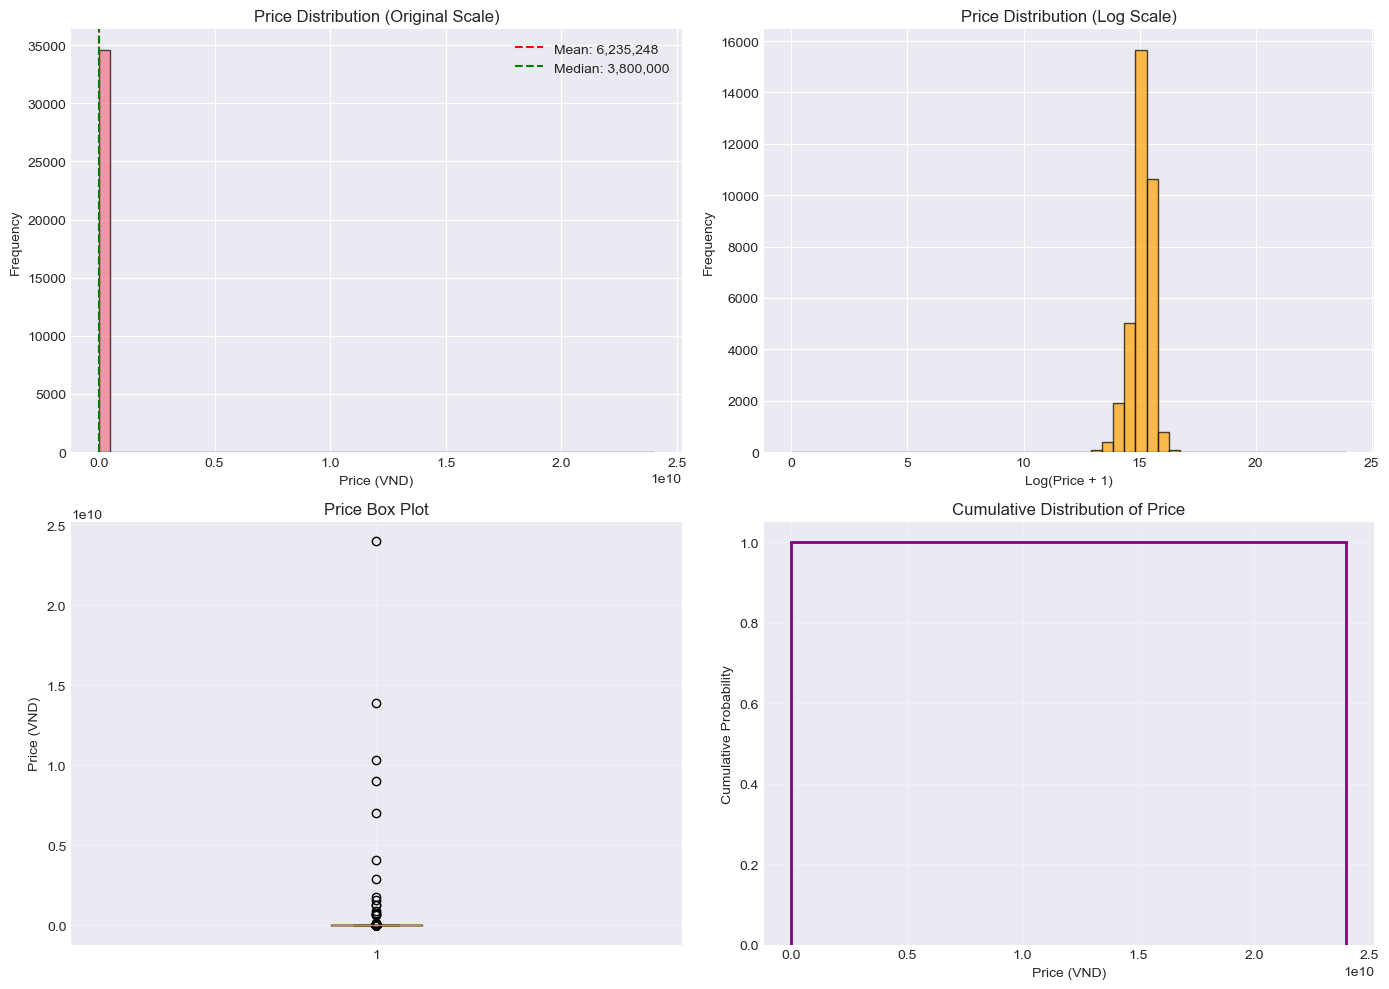


💡 Price Insights:
   • Mean > Median: Yes (right-skewed)
   • Price range spread: 24,000,000,000 VND
   • Coefficient of variation: 2781.0%


In [72]:
# Price statistics
print("="*70)
print("TARGET VARIABLE: PRICE (VND)")
print("="*70)

price_valid = df['price'].dropna()

stats_dict = {
    'Count': f"{len(price_valid):,}",
    'Missing': f"{df['price'].isnull().sum():,} ({df['price'].isnull().sum()/len(df)*100:.2f}%)",
    'Mean': f"{price_valid.mean():,.0f}",
    'Median': f"{price_valid.median():,.0f}",
    'Std Dev': f"{price_valid.std():,.0f}",
    'CV (%)': f"{(price_valid.std() / price_valid.mean() * 100):.1f}",
    'Min': f"{price_valid.min():,.0f}",
    'Max': f"{price_valid.max():,.0f}",
    'Q1 (25%)': f"{price_valid.quantile(0.25):,.0f}",
    'Q3 (75%)': f"{price_valid.quantile(0.75):,.0f}",
    'IQR': f"{price_valid.quantile(0.75) - price_valid.quantile(0.25):,.0f}"
}

for key, value in stats_dict.items():
    print(f"{key:.<25} {value}")

# Visualize price distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(price_valid, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Price (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Original Scale)')
axes[0, 0].axvline(price_valid.mean(), color='red', linestyle='--', label=f'Mean: {price_valid.mean():,.0f}')
axes[0, 0].axvline(price_valid.median(), color='green', linestyle='--', label=f'Median: {price_valid.median():,.0f}')
axes[0, 0].legend()

# Log-scale histogram
axes[0, 1].hist(np.log1p(price_valid), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Log(Price + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Price Distribution (Log Scale)')

# Box plot
axes[1, 0].boxplot(price_valid, vert=True)
axes[1, 0].set_ylabel('Price (VND)')
axes[1, 0].set_title('Price Box Plot')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative distribution
axes[1, 1].hist(price_valid, bins=50, cumulative=True, density=True, 
                histtype='step', linewidth=2, color='purple')
axes[1, 1].set_xlabel('Price (VND)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Price')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Price Insights:")
print(f"   • Mean > Median: {'Yes' if price_valid.mean() > price_valid.median() else 'No'} ({'right-skewed' if price_valid.mean() > price_valid.median() else 'left-skewed or symmetric'})")
print(f"   • Price range spread: {price_valid.max() - price_valid.min():,.0f} VND")
print(f"   • Coefficient of variation: {(price_valid.std() / price_valid.mean() * 100):.1f}%")

In [73]:
# Outlier detection for price using IQR method
Q1 = price_valid.quantile(0.25)
Q3 = price_valid.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("="*70)
print("PRICE OUTLIER ANALYSIS (IQR Method)")
print("="*70)
print(f"\nLower bound: {lower_bound:,.0f} VND")
print(f"Upper bound: {upper_bound:,.0f} VND")
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"\nPrice range of outliers:")
if len(outliers) > 0:
    print(f"   • Min: {outliers['price'].min():,.0f} VND")
    print(f"   • Max: {outliers['price'].max():,.0f} VND")
    print(f"   • Mean: {outliers['price'].mean():,.0f} VND")
    
# Show some outlier examples
if len(outliers) > 0:
    print(f"\n🔍 Sample outliers:")
    print(outliers[['price', 'area', 'district', 'is_full_furniture']].head(10))

PRICE OUTLIER ANALYSIS (IQR Method)

Lower bound: 50,000 VND
Upper bound: 7,650,000 VND

Outliers detected: 671 (1.93%)

Price range of outliers:
   • Min: 0 VND
   • Max: 24,000,000,000 VND
   • Mean: 130,233,212 VND

🔍 Sample outliers:
             price   area    district  is_full_furniture
17      8500000.00  40.00  bình thạnh              False
23      8500000.00  35.00  bình thạnh               True
56      8700000.00  45.00   phú nhuận               True
60      8200000.00  30.00  bình thạnh               True
100     8500000.00  20.00           1               True
116     7800000.00  35.00           7               True
190     8000000.00  55.00  bình thạnh              False
228 10300000000.00 253.00      nhà bè              False
271    15000000.00  60.00           3               True
276     8000000.00  25.00           3               True


## 3. Phân tích các đặc trưng dạng số (Numerical Features)

NUMERICAL FEATURES SUMMARY

📊 PRICE
Valid values: 34,632 | Missing: 55 (0.16%)
Range: [0, 24,000,000,000]
Mean: 6,235,248 | Median: 3,800,000 | Std: 173,403,529
CV: 2781.0%

📊 AREA
Valid values: 34,685 | Missing: 2 (0.01%)
Range: [0, 3,200,000]
Mean: 227 | Median: 25 | Std: 22,908
CV: 10111.8%

CORRELATION ANALYSIS


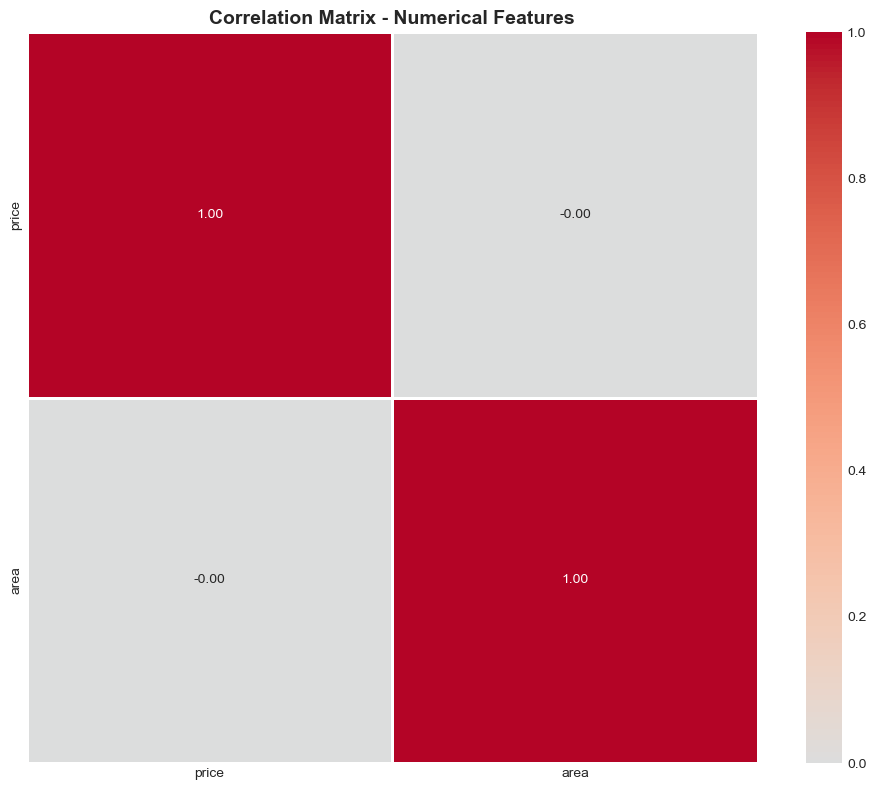


🎯 Correlations with Price:
   area..........................  -0.000


In [74]:
# Analyze all numerical features
print("="*70)
print("NUMERICAL FEATURES SUMMARY")
print("="*70)

for col in numerical_cols:
    if col in df.columns:
        valid_data = df[col].dropna()
        missing_pct = df[col].isnull().sum() / len(df) * 100
        
        print(f"\n{'='*70}")
        print(f"📊 {col.upper()}")
        print(f"{'='*70}")
        print(f"Valid values: {len(valid_data):,} | Missing: {df[col].isnull().sum():,} ({missing_pct:.2f}%)")
        
        if len(valid_data) > 0:
            print(f"Range: [{valid_data.min():,.0f}, {valid_data.max():,.0f}]")
            print(f"Mean: {valid_data.mean():,.0f} | Median: {valid_data.median():,.0f} | Std: {valid_data.std():,.0f}")
            print(f"CV: {(valid_data.std() / valid_data.mean() * 100):.1f}%")
            
            # Check for unrealistic values
            if col.endswith('_price'):
                unrealistic = valid_data[(valid_data < 1000) | (valid_data > 1000000)]
                if len(unrealistic) > 0:
                    print(f"⚠️  Warning: {len(unrealistic)} unrealistic values (< 1k or > 1M VND)")

# Correlation matrix for numerical features
print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

numeric_df = df[numerical_cols].dropna()
if len(numeric_df) > 0:
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show correlations with price
    price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
    print("\n🎯 Correlations with Price:")
    for feat, corr_val in price_corr.items():
        print(f"   {feat:.<30} {corr_val:>7.3f}")

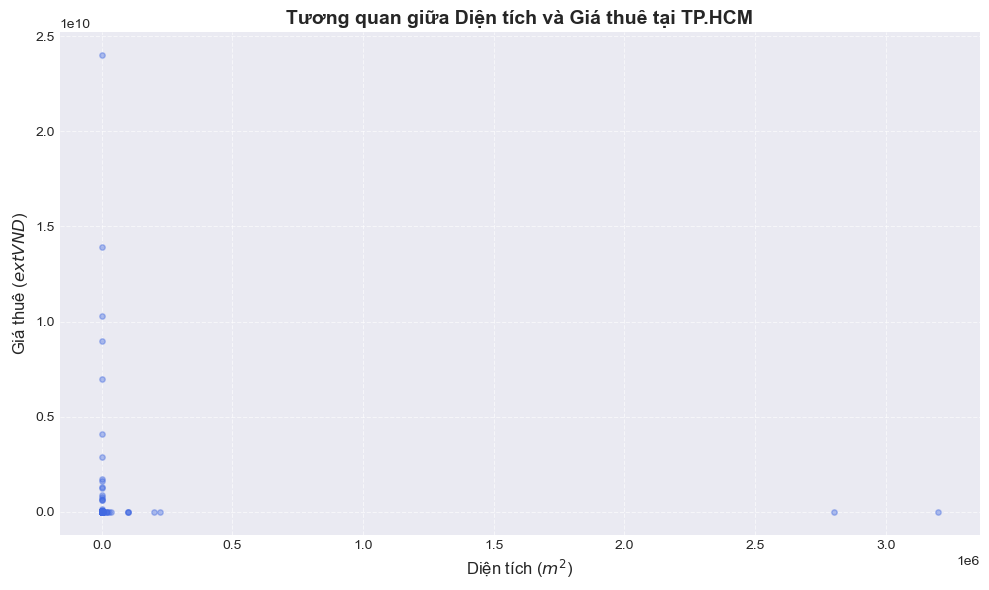

In [75]:
# 1. Lọc dữ liệu không bị khuyết để tránh lỗi khi vẽ
valid_mask = df['area'].notna() & df['price'].notna()
valid_df = df[valid_mask]

# 2. Khởi tạo biểu đồ đơn
if len(valid_df) > 0:
    # Thiết kế kích thước biểu đồ
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Vẽ biểu đồ phân tán (Scatter plot)
    ax.scatter(valid_df['area'], valid_df['price'], alpha=0.4, s=15, color='royalblue')
    
    # Thiết lập nhãn và tiêu đề bằng tiếng Việt (có định dạng LaTeX cho đơn vị)
    ax.set_xlabel('Diện tích ($m^2$)', fontsize=12)
    ax.set_ylabel('Giá thuê ($\text{VND}$)', fontsize=12)
    ax.set_title('Tương quan giữa Diện tích và Giá thuê tại TP.HCM', fontsize=14, fontweight='bold')
    
    # Thêm lưới để dễ quan sát
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Tối ưu hóa khoảng cách
    plt.tight_layout()
    
    plt.show() # Bỏ comment nếu chạy trên máy cá nhân
else:
    print("Không có đủ dữ liệu hợp lệ để vẽ biểu đồ.")

**Nhận xét**: các chỉ số trên bị phá trầm trọng bởi outlier

## 4. Phân tích các đặc trưng phân loại (Categorical Features)

In [92]:
# Analyze categorical features
print("="*70)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*70)

cat_features_to_analyze = ['area_group', 'toilet_type', 'washing_machine_type', 'lock_type', 'water_type', 'source']

for col in cat_features_to_analyze:
    if col in df.columns:
        print(f"\n{'='*70}")
        print(f"🏷️  {col.upper()}")
        print(f"{'='*70}")
        
        value_counts = df[col].value_counts(dropna=False)
        missing_count = df[col].isnull().sum()
        
        print(f"Unique values: {df[col].nunique()}")
        print(f"Missing: {missing_count:,} ({missing_count/len(df)*100:.2f}%)")
        print(f"\nValue distribution:")
        
        for val, count in value_counts.items():
            pct = count / len(df) * 100
            print(f"   {str(val):.<35} {count:>6,} ({pct:>5.2f}%)")
        
        # Calculate mean price per category
        if len(df[df[col].notna()]) > 0:
            price_by_cat = df.groupby(col)['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
            print(f"\n💰 Price by {col}:")
            print(price_by_cat.to_string())

CATEGORICAL FEATURES ANALYSIS

🏷️  AREA_GROUP
Unique values: 7
Missing: 0 (0.00%)

Value distribution:
   near_center........................  9,926 (28.62%)
   west...............................  5,714 (16.47%)
   east...............................  5,675 (16.36%)
   outer..............................  5,363 (15.46%)
   center.............................  4,688 (13.52%)
   south..............................  3,297 ( 9.51%)
   unknown............................     24 ( 0.07%)

💰 Price by area_group:
                   mean     median  count
area_group                               
south       14459262.46 4000000.00   3281
outer        9906975.70 3500000.00   5359
center       5840230.39 4500000.00   4679
near_center  4500748.57 4500000.00   9906
east         4124840.14 3400000.00   5673
west         3508414.50 3300000.00   5711
unknown      2571744.48 2500000.00     23

🏷️  WASHING_MACHINE_TYPE
Unique values: 2
Missing: 24,657 (71.08%)

Value distribution:
   None..............

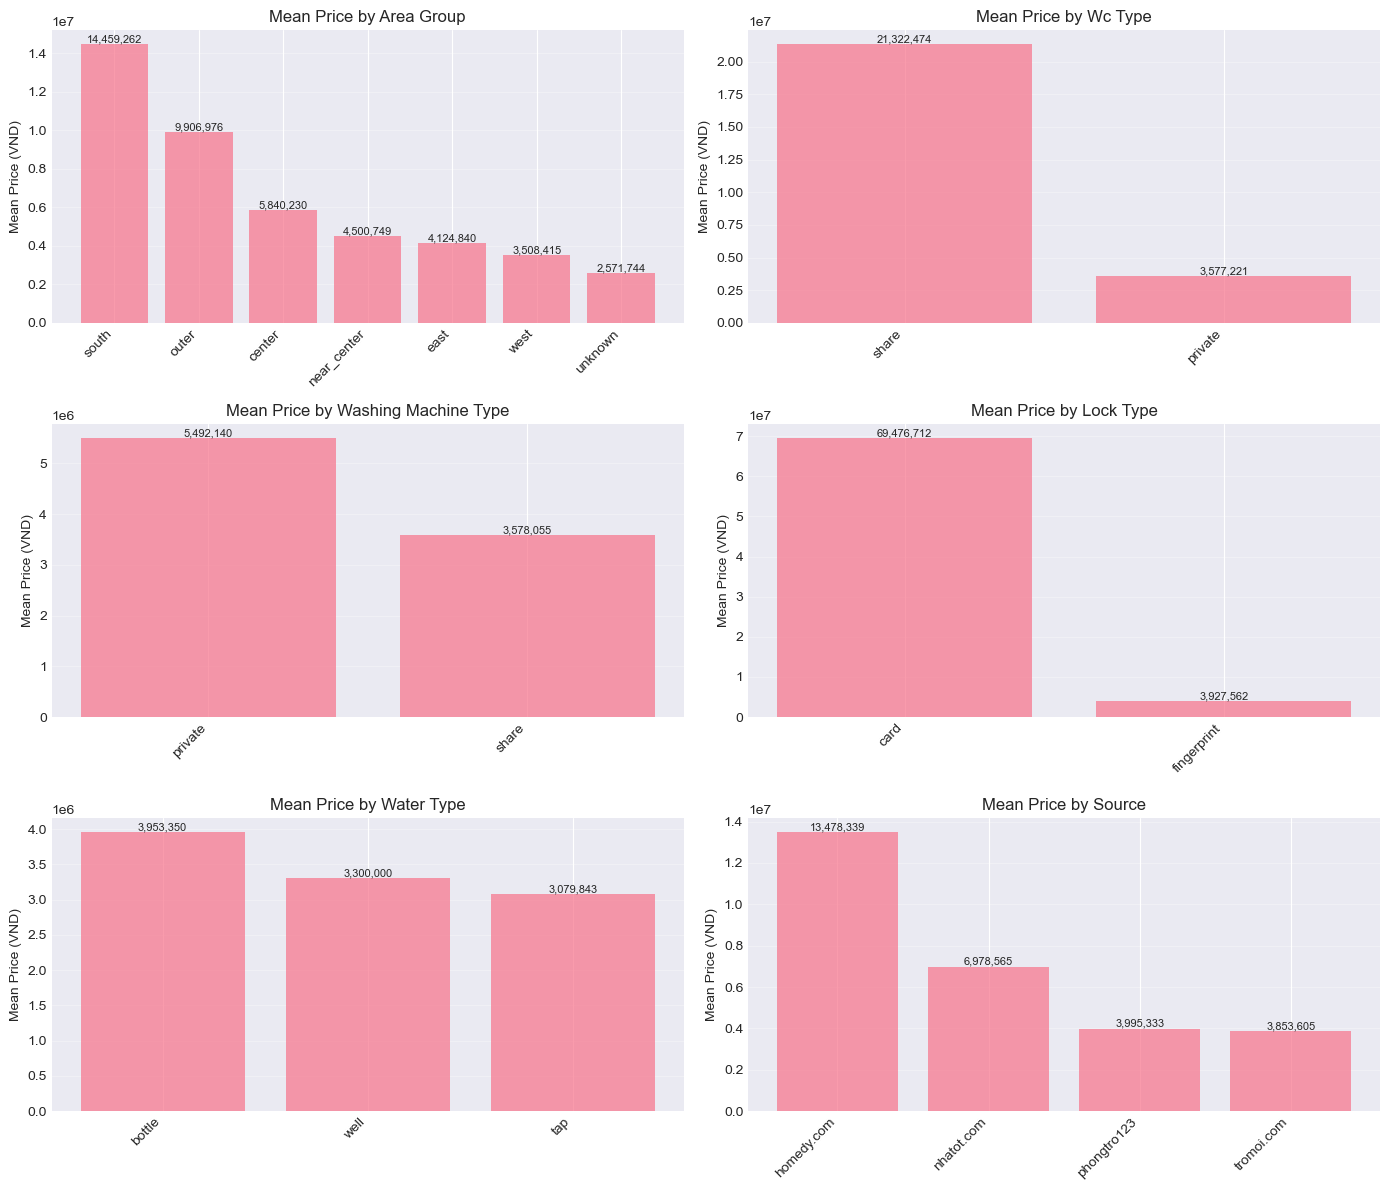

In [93]:
# Visualize categorical features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

viz_features = ['area_group', 'wc_type', 'washing_machine_type', 'lock_type', 'water_type', 'source']

for idx, col in enumerate(viz_features):
    if col in df.columns and idx < len(axes):
        valid_data = df[df[col].notna()]
        
        if len(valid_data) > 0:
            # Bar plot with price
            price_by_cat = valid_data.groupby(col)['price'].mean().sort_values(ascending=False)
            
            axes[idx].bar(range(len(price_by_cat)), price_by_cat.values, alpha=0.7)
            axes[idx].set_xticks(range(len(price_by_cat)))
            axes[idx].set_xticklabels(price_by_cat.index, rotation=45, ha='right')
            axes[idx].set_ylabel('Mean Price (VND)')
            axes[idx].set_title(f'Mean Price by {col.replace("_", " ").title()}')
            axes[idx].grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for i, v in enumerate(price_by_cat.values):
                axes[idx].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Phân tích các đặc trưng nhị phân (Binary Features)

In [94]:
# Analyze binary features
print("="*70)
print("BINARY FEATURES ANALYSIS")
print("="*70)

# Calculate prevalence and price impact
binary_analysis = []

for col in binary_cols:
    if col in df.columns:
        prevalence = df[col].sum() / len(df) * 100
        
        # Calculate price difference
        price_with = df[df[col] == True]['price'].mean()
        price_without = df[df[col] == False]['price'].mean()
        price_diff = price_with - price_without
        price_diff_pct = (price_diff / price_without * 100) if price_without > 0 else 0
        
        binary_analysis.append({
            'Feature': col,
            'Prevalence (%)': prevalence,
            'Price with': price_with,
            'Price without': price_without,
            'Price Diff': price_diff,
            'Price Diff (%)': price_diff_pct
        })

binary_df = pd.DataFrame(binary_analysis).sort_values('Price Diff (%)', ascending=False)

print("\n📊 Top 15 Binary Features by Price Impact:")
print(binary_df.head(15)[['Feature', 'Prevalence (%)', 'Price Diff', 'Price Diff (%)']].to_string(index=False))

print("\n\n📊 Bottom 10 Binary Features by Price Impact:")
print(binary_df.tail(10)[['Feature', 'Prevalence (%)', 'Price Diff', 'Price Diff (%)']].to_string(index=False))

BINARY FEATURES ANALYSIS

📊 Top 15 Binary Features by Price Impact:
          Feature  Prevalence (%)  Price Diff  Price Diff (%)
 near_supermarket           13.57  3061035.63           52.60
      has_balcony           22.20  1758429.91           30.08
      near_school           35.15  -654709.07          -10.13
         has_sofa            1.72 -1021428.77          -16.34
      near_market           15.20 -1556596.39          -24.05
        is_duplex           29.11 -2050422.23          -30.01
          has_bed           18.98 -2607346.78          -38.74
     has_wardrobe           19.29 -2644293.89          -39.20
       has_fridge           21.58 -2756796.18          -40.36
     has_mattress           15.14 -2701224.43          -40.65
       has_window           28.76 -2907917.50          -41.13
      has_parking           24.02 -3057979.05          -43.87
       has_camera           24.55 -3088221.95          -44.16
is_full_furniture           52.77 -3692434.40          -45.11
  

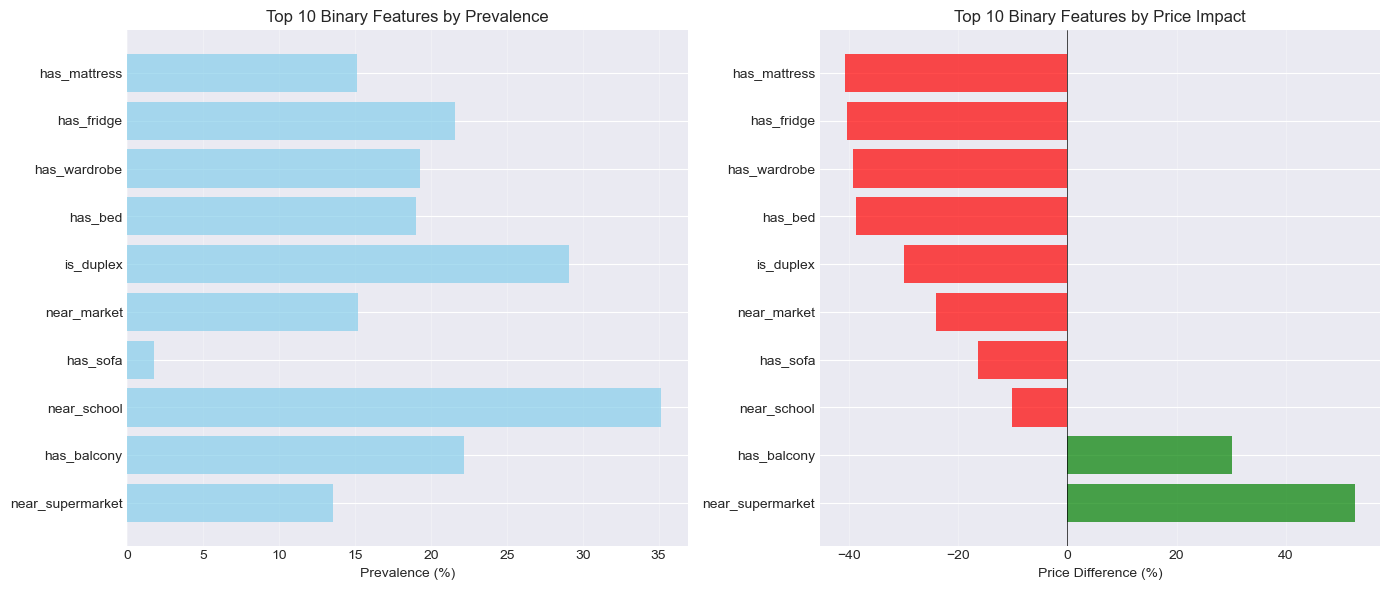

In [95]:
# Visualize top binary features impact
top_features = binary_df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prevalence
axes[0].barh(range(len(top_features)), top_features['Prevalence (%)'].values, alpha=0.7, color='skyblue')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'].values)
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_title('Top 10 Binary Features by Prevalence')
axes[0].grid(True, alpha=0.3, axis='x')

# Price impact
colors = ['green' if x > 0 else 'red' for x in top_features['Price Diff (%)'].values]
axes[1].barh(range(len(top_features)), top_features['Price Diff (%)'].values, alpha=0.7, color=colors)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['Feature'].values)
axes[1].set_xlabel('Price Difference (%)')
axes[1].set_title('Top 10 Binary Features by Price Impact')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Xử lý dữ liệu khuyết thiếu (Missing Data)

MISSING DATA ANALYSIS

Features with missing data: 12

               Feature  Missing Count  Missing (%) Data Type
               wc_type          29744        85.75    object
            water_type          27727        79.93    object
 mention_service_price          27144        78.25    object
  washing_machine_type          24657        71.08    object
             lock_type          23339        67.28    object
mention_electric_price          22650        65.30    object
   mention_water_price          21372        61.61    object
                  ward           2063         5.95    object
                 price             55         0.16   float64
              district             24         0.07    object
           description             12         0.03    object
                  area              2         0.01   float64


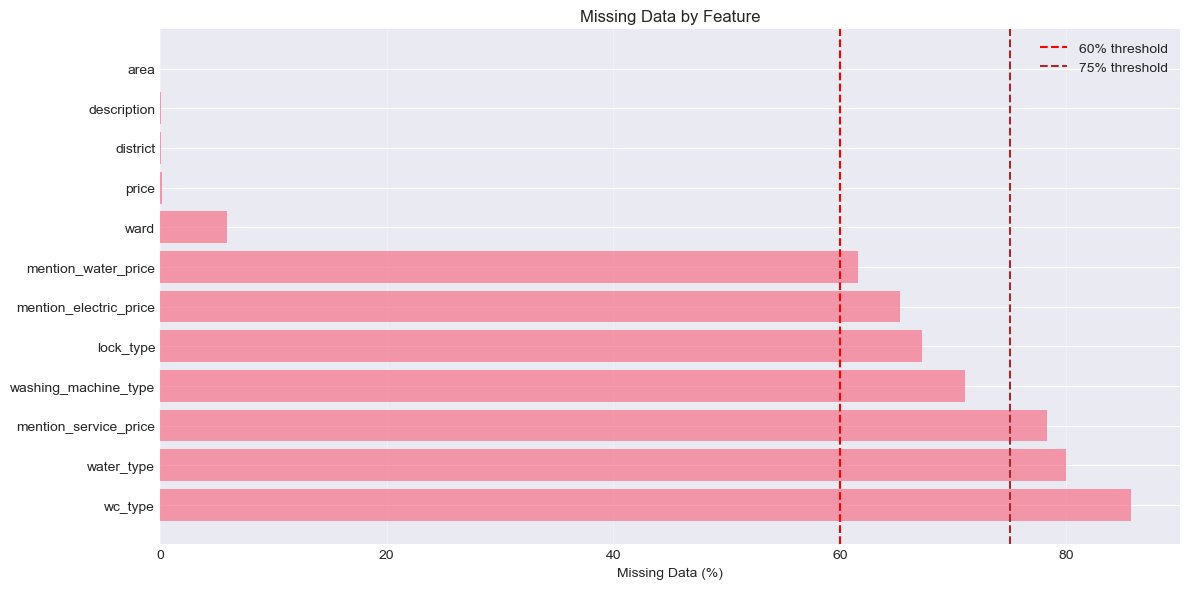

In [96]:
# Comprehensive missing data analysis
print("="*70)
print("MISSING DATA ANALYSIS")
print("="*70)

missing_data = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_pct = missing_count / len(df) * 100
        missing_data.append({
            'Feature': col,
            'Missing Count': missing_count,
            'Missing (%)': missing_pct,
            'Data Type': df[col].dtype
        })


missing_df = pd.DataFrame(missing_data).sort_values('Missing (%)', ascending=False)

print(f"\nFeatures with missing data: {len(missing_df)}")
print("\n" + missing_df.to_string(index=False))

# Visualize missing data
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(missing_df)), missing_df['Missing (%)'].values, alpha=0.7)
    plt.yticks(range(len(missing_df)), missing_df['Feature'].values)
    plt.xlabel('Missing Data (%)')
    plt.title('Missing Data by Feature')
    plt.axvline(x=60, color='red', linestyle='--', label='60% threshold')
    plt.axvline(x=75, color='brown', linestyle='--', label='75% threshold')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

**Chiến thuật xử lí các cột bị thiếu trên 60%**
- Đối với cột **mention_electric_price**,**mention_water_price**,**mention_service_price**: ta thấy giá nước và giá điện được đề cập 40%, tuy nhiên thực tế khi chủ trọ muốn cho thông tin giá điện, nước thì cũng sẽ cho giá dịch vụ **mention_service_price**, việc **mention_electric_price**, **mention_water_price** chỉ gần 70% là chưa chính xác vì có thể các từ làm nhiễu như điện thoại, xe điệp, đồng hồ nước riêng đã làm đẹp chỉ số lên, do đó, thực tế số tiền điện, nước, dịch vụ được đề cập thiếu gần 80%, đây là một chiến thuật của chủ trọ nhằm giấu thông tin xấu để thu hút thêm nhiều khách tìm trọ chủ động nhắn để có thể thuyết phục, do đó em cũng sẽ bỏ 3 cột này.
- Đối với cột **wc_type**,**water_type**,**washing_machine_type**,**lock_type**: em nghĩ nó có giá trị vì đây là nhưng thông tin mà chủ trọ sẽ đăng nhằm tăng sự hấp dẫn đối với người tìm trọ, nên chủ trọ sẽ không giấu, do đó thông tin ở các cột này chính xác.


In [97]:
missing_col=['mention_electric_price','mention_water_price','mention_service_price']

## 7. Phát hiện & Xử lý giá trị ngoại lai (Outliers)

**Chiến lược xử lý dựa trên phân tích (với các cải tiến):**

1. **Phát hiện và loại bỏ các dòng trùng lặp hoàn toàn (Exact Duplicates):** Làm sạch các bản ghi bị lặp lại trong quá trình thu thập dữ liệu.
2. **Loại bỏ các bản ghi gần trùng (Near-duplicates/Spam):** Xác định và xóa bỏ các tin đăng lặp lại (spam) dựa trên sự trùng khớp của các cột đặc trưng như `ward`, `price`, `area`, `street`, và `district`.
3. **Loại bỏ các dòng thiếu biến mục tiêu (Price):** Xóa các bản ghi không có thông tin giá thuê vì đây là biến cần dự báo.
4. **Xử lý ngoại lai cho biến Giá (Price):** Sử dụng các ngưỡng tính toán tự động từ dữ liệu (**IQR + Quantiles**) thay vì áp đặt các con số cố định theo cảm tính (hard-code) để đảm bảo tính khách quan.
5. **Xử lý ngoại lai cho Diện tích (Area):** Áp dụng phương pháp ngưỡng tự tính toán tương tự như biến Giá để loại bỏ các thông số diện tích phi thực tế.
6. **Làm sạch & Gán giá trị (Impute) cho chi phí dịch vụ:** Sử dụng các ngưỡng dựa trên phân vị của từng cột thay vì các mốc cố định để thích ứng tốt hơn với phân bổ thực tế của dữ liệu.
7. **Xử lý dữ liệu phân loại bị thiếu:** Thực hiện gán giá trị (impute), tạo nhóm 'unknown' (không xác định) hoặc loại bỏ các dòng thiếu thông tin địa lý bắt buộc (như `district`, `area_group`).
8. **Loại bỏ các cột dạng văn bản:** Loại bỏ các cột không cần thiết cho các mô hình học máy dạng bảng cơ bản (như `url`, `description`, `title`) để tối ưu hóa bộ nhớ.

In [98]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*70)
print("DATA CLEANING PROCESS")
print("="*70)

# Step 0: Detect and remove exact duplicates
initial_rows = len(df_clean)
exact_dupes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\n0️⃣  Removed {exact_dupes:,} exact duplicate rows")
print(f"   Remaining: {len(df_clean):,} rows")

# Step 0.5: Detect and remove near-duplicates (spam detection)
# Near-duplicate: same ward + same price + same area + same street + same district
print(f"\n🔍 Detecting near-duplicates (spam posts)...")
near_dup_cols = ['ward', 'price', 'area','street','district']
before_spam = len(df_clean)

# Keep first occurrence, mark rest as duplicates
spam_mask = df_clean.duplicated(subset=near_dup_cols, keep='first')
spam_count = spam_mask.sum()

if spam_count > 0:
    print(f"   Found {spam_count:,} potential spam/reposted listings")
    print(f"   Example spam patterns:")
    spam_examples = df_clean[spam_mask][near_dup_cols].head(5)
    for idx, row in spam_examples.iterrows():
        print(f"      • Quận {row['district']} Phường {row['ward']} Đường {row['street']} | {row['price']:,.0f} VND | {row['area']:.0f}m²")
    
    df_clean = df_clean[~spam_mask]
    print(f"\n0️⃣.5 Removed {spam_count:,} near-duplicate/spam rows")
    print(f"   Remaining: {len(df_clean):,} rows")


# Step 1: Remove rows with missing price (target variable)
before_price = len(df_clean)
df_clean = df_clean[df_clean['price'].notna()]
print(f"\n1️⃣  Removed {before_price - len(df_clean):,} rows with missing price")
print(f"   Remaining: {len(df_clean):,} rows")

# Step 2: Handle price outliers (data-driven thresholds instead of hard-coded domain range)
# Use robust IQR + quantile-based bounds so that thresholds adapt to the dataset
price_series = df_clean['price'].dropna()

if len(price_series) > 0:
    # Basic quantile range
    q1, q3 = price_series.quantile([0.25, 0.75])
    iqr = q3 - q1

    # IQR-based bounds (more lenient upper bound to keep rare-but-valid high prices)
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 3.0 * iqr

    # Clip to 1st–99th percentile to avoid extreme tails driving the bounds
    p1, p99 = price_series.quantile([0.01, 0.99])
    lower_bound = max(iqr_lower, p1)
    upper_bound = min(iqr_upper, p99)

    before_outlier = len(df_clean)
    df_clean = df_clean[(df_clean['price'] >= lower_bound) & (df_clean['price'] <= upper_bound)]
    removed = before_outlier - len(df_clean)
    print(f"\n2️⃣  Removed {removed:,} price outliers outside [{lower_bound:,.0f}, {upper_bound:,.0f}] VND")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("\n2️⃣  Skipped price outlier handling (no non-null price values)")

# Step 3: Handle area outliers (also data-driven)
area_series = df_clean['area'].dropna()

if len(area_series) > 0:
    a_q1, a_q3 = area_series.quantile([0.25, 0.75])
    a_iqr = a_q3 - a_q1

    a_iqr_lower = a_q1 - 1.5 * a_iqr
    a_iqr_upper = a_q3 + 3.0 * a_iqr

    a_p1, a_p99 = area_series.quantile([0.01, 0.99])
    area_lower = max(a_iqr_lower, a_p1)
    area_upper = min(a_iqr_upper, a_p99)

    before_area = len(df_clean)
    df_clean = df_clean[(df_clean['area'] >= area_lower) & (df_clean['area'] <= area_upper)]
    removed_area = before_area - len(df_clean)
    print(f"\n3️⃣  Removed {removed_area:,} area outliers outside [{area_lower:.1f}, {area_upper:.1f}] m²")
    print(f"   Remaining: {len(df_clean):,} rows")
else:
    print("\n3️⃣  Skipped area outlier handling (no non-null area values)")




# Step 6: Handle categorical missing values
print(f"\n6️⃣  Handling categorical missing values:")

# For categorical features with high missing rate, create 'unknown' category
cat_to_fill = ['washing_machine_type', 'wc_type', 'lock_type', 'water_type']
for col in cat_to_fill:
    if col in df_clean.columns:
        missing_count = df_clean[col].isnull().sum()
        if missing_count > 0:
            df_clean[col].fillna('unknown', inplace=True)
            print(f"   {col}: filled {missing_count:,} with 'unknown'")

# For area_group, district - drop rows with missing (location is important)
location_cols = ['area_group', 'district']
for col in location_cols:
    if col in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean[col].notna()]
        removed = before - len(df_clean)
        if removed > 0:
            print(f"   {col}: removed {removed:,} rows with missing values")

# Summary
total_removed = initial_rows - len(df_clean)
print(f"\n{'='*70}")
print(f"✅ Cleaning complete!")
print(f"{'='*70}")
print(f"   Original dataset: {initial_rows:,} rows")
print(f"   Final dataset: {len(df_clean):,} rows × {df_clean.shape[1]} columns")
print(f"   Total removed: {total_removed:,} rows ({total_removed/initial_rows*100:.2f}%)")
print(f"   Retention rate: {len(df_clean)/initial_rows*100:.2f}%")

DATA CLEANING PROCESS

0️⃣  Removed 69 exact duplicate rows
   Remaining: 34,618 rows

🔍 Detecting near-duplicates (spam posts)...
   Found 4,814 potential spam/reposted listings
   Example spam patterns:
      • Quận gò vấp Phường 17 Đường 5 | 4,400,000 VND | 35m²
      • Quận phú nhuận Phường 2 Đường phan xích long | 5,500,000 VND | 35m²
      • Quận bình tân Phường tân tạo Đường xa lộ đại hàn | 500,000 VND | 20m²
      • Quận bình thạnh Phường 21 Đường xô viết nghệ tĩnh | 950,000 VND | 20m²
      • Quận 6 Phường 10 Đường an dương vương | 2,500,000 VND | 20m²

0️⃣.5 Removed 4,814 near-duplicate/spam rows
   Remaining: 29,804 rows

1️⃣  Removed 50 rows with missing price
   Remaining: 29,754 rows

2️⃣  Removed 507 price outliers outside [1,000,000, 9,000,000] VND
   Remaining: 29,247 rows

3️⃣  Removed 562 area outliers outside [10.0, 60.0] m²
   Remaining: 28,685 rows

6️⃣  Handling categorical missing values:
   washing_machine_type: filled 20,538 with 'unknown'
   wc_type: filled 2

### Ghi chú Cải tiến: Xử lý Giá trị ngoại lai (Outlier)

Trong phiên bản này, việc **xử lý giá trị ngoại lai cho các cột `price` (giá), `area` (diện tích) và các cột chi phí dịch vụ** đã được điều chỉnh:

- Thay vì sử dụng các ngưỡng cố định như `500k–30M`, `5–200m²`, `1.000–1.000.000` (dựa thuần túy vào kiến thức thực tế), hiện tại chúng tôi sử dụng **các ngưỡng tự động được trích xuất từ chính dữ liệu**:
  - Kết hợp phương pháp **IQR (Q1, Q3)** và **phân vị từ 1% đến 99% (1st–99th percentiles)** để xác định các khoảng giá và diện tích hợp lý.
  - Các ngưỡng này có khả năng **tự thích ứng với bộ dữ liệu** (phù hợp với các thành phố khác nhau, các khoảng thời gian khác nhau hoặc các phân khúc thị trường khác nhau) mà không cần thay đổi mã nguồn.



Cách tiếp cận này mang lại:
- Một **quy trình (pipeline) tổng quát hơn**, dễ dàng tái sử dụng cho các bộ dữ liệu khác nhau.
- Tránh việc phụ thuộc quá mức vào các ngưỡng do người phân tích tự chọn dựa trên cảm tính cá nhân.

In [99]:
# Verify cleaning results
print("="*70)
print("POST-CLEANING VALIDATION")
print("="*70)

print(f"\n📊 Dataset shape: {df_clean.shape}")
print(f"\n💰 Price statistics:")
print(df_clean['price'].describe())

print(f"\n📏 Area statistics:")
print(df_clean['area'].describe())

print(f"\n❌ Remaining missing values:")
remaining_missing = df_clean.isnull().sum()
if remaining_missing.sum() == 0:
    print("   ✅ No missing values!")
else:
    print(remaining_missing[remaining_missing > 0])

# Check data quality
print(f"\n✅ Data Quality Checks:")
print(f"   • All prices in valid range: {df_clean['price'].between(500000, 30000000).all()}")
print(f"   • All areas in valid range: {df_clean['area'].between(5, 200).all()}")
print(f"   • No missing target: {df_clean['price'].isnull().sum() == 0}")
print(f"   • No duplicates: {df_clean.duplicated().sum() == 0}")

POST-CLEANING VALIDATION

📊 Dataset shape: (28666, 37)

💰 Price statistics:
count     28666.00
mean    3889487.56
std     1443242.90
min     1000000.00
25%     2900000.00
50%     3800000.00
75%     4800000.00
max     9000000.00
Name: price, dtype: float64

📏 Area statistics:
count   28666.00
mean       26.56
std         8.33
min        10.00
25%        20.00
50%        25.00
75%        30.00
max        60.00
Name: area, dtype: float64

❌ Remaining missing values:
ward                       1806
mention_electric_price    18661
mention_water_price       17669
mention_service_price     22401
dtype: int64

✅ Data Quality Checks:
   • All prices in valid range: True
   • All areas in valid range: True
   • No missing target: True
   • No duplicates: True


## 8. Kỹ thuật đặc trưng (Feature Engineering) & Lựa chọn đặc trưng

In [100]:
# Create new features
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

# 1. Price per square meter
df_clean['price_per_sqm'] = df_clean['price'] / df_clean['area']
print(f"\n✅ Created: price_per_sqm")

# 2. Total utility cost
# utility_price_cols = ['electric_price', 'water_price', 'garbage_price', 'service_price']
# df_clean['total_utility_cost'] = df_clean[utility_price_cols].sum(axis=1)
# print(f"✅ Created: total_utility_cost")

# 3. Amenities score (count of amenities)
amenity_cols = [col for col in binary_cols if col.startswith('has_')]
df_clean['amenity_score'] = df_clean[amenity_cols].sum(axis=1)
print(f"✅ Created: amenity_score (sum of {len(amenity_cols)} amenities)")

# 4. Location convenience score
location_cols = [col for col in binary_cols if col.startswith('near_')]
df_clean['location_score'] = df_clean[location_cols].sum(axis=1)
print(f"✅ Created: location_score (sum of {len(location_cols)} proximity features)")

# 5. Has private facilities flag
if 'wc_type' in df_clean.columns and 'washing_machine_type' in df_clean.columns:
    df_clean['has_private_facilities'] = (
        (df_clean['wc_type'] == 'private') & 
        (df_clean['washing_machine_type'] == 'private')
    ).astype(int)
    print(f"✅ Created: has_private_facilities")

# 6. Security score
security_features = ['has_camera', 'has_security', 'lock_type']
security_score = 0
if 'has_camera' in df_clean.columns:
    security_score += df_clean['has_camera'].astype(int)
if 'has_security' in df_clean.columns:
    security_score += df_clean['has_security'].astype(int)
if 'lock_type' in df_clean.columns:
    security_score += (df_clean['lock_type'].isin(['fingerprint', 'card'])).astype(int)

df_clean['security_score'] = security_score
print(f"✅ Created: security_score")

print(f"\n📊 New feature statistics:")
new_features = ['price_per_sqm', 'amenity_score', 'location_score', 'security_score']
print(df_clean[new_features].describe())

FEATURE ENGINEERING

✅ Created: price_per_sqm
✅ Created: amenity_score (sum of 13 amenities)
✅ Created: location_score (sum of 3 proximity features)
✅ Created: has_private_facilities
✅ Created: security_score

📊 New feature statistics:
       price_per_sqm  amenity_score  location_score  security_score
count       28666.00       28666.00        28666.00        28666.00
mean       152611.07           3.27            0.63            1.08
std         52565.51           2.51            0.73            1.01
min         16666.67           0.00            0.00            0.00
25%        120000.00           1.00            0.00            0.00
50%        150000.00           3.00            0.00            1.00
75%        183333.33           5.00            1.00            2.00
max        800000.00          13.00            3.00            3.00


### Biến đổi Log cho biến mục tiêu (Price)

Vì phân phối của biến `price` (giá) có độ lệch phải rất lớn (right-skewed), chúng tôi thực hiện biến đổi logarit cho biến mục tiêu để hỗ trợ các mô hình tuyến tính:

- `log_price = log1p(price)`
- Giúp giảm bớt ảnh hưởng của các giá trị cực lớn (extreme values).
- Tạo ra một phân phối gần với phân phối chuẩn (normal distribution) hơn, từ đó cải thiện tính ổn định của mô hình đối với các sai số tương đối.

In [101]:
# Create log-transformed target
df_clean['log_price'] = np.log1p(df_clean['price'])

print("\n✅ Created: log_price (log1p of price)")
print("\n📊 log_price summary:")
print(df_clean['log_price'].describe())



✅ Created: log_price (log1p of price)

📊 log_price summary:
count   28666.00
mean       15.10
std         0.41
min        13.82
25%        14.88
50%        15.15
75%        15.38
max        16.01
Name: log_price, dtype: float64


### Tương quan giữa các đặc trưng chính và (log_)price

Để định lượng các quan sát từ phần phân tích EDA, chúng tôi tiến hành tính toán nhanh hệ số tương quan Pearson giữa một số đặc trưng đã được trích xuất (engineered features) với cả hai biến `price` (giá gốc) và `log_price` (giá sau biến đổi log).

In [102]:
# Compute correlation with price and log_price for selected features
corr_features = ['area', 'price_per_sqm', 'amenity_score', 'location_score', 'security_score', 'total_utility_cost']
targets = ['price', 'log_price']

available_feats = [f for f in corr_features if f in df_clean.columns]
available_targets = [t for t in targets if t in df_clean.columns]

corr_results = {}

for t in available_targets:
    corr_results[t] = df_clean[available_feats + [t]].corr()[t].drop(t)

print("\n📊 Correlation with target variables:")
for t in available_targets:
    print(f"\n=== Correlation with {t} ===")
    print(corr_results[t].sort_values(ascending=False))



📊 Correlation with target variables:

=== Correlation with price ===
price_per_sqm     0.58
area              0.46
amenity_score     0.09
security_score    0.03
location_score   -0.07
Name: price, dtype: float64

=== Correlation with log_price ===
price_per_sqm     0.60
area              0.42
amenity_score     0.09
security_score    0.03
location_score   -0.06
Name: log_price, dtype: float64


In [103]:
# Feature selection: remove unnecessary columns
print("="*70)
print("FEATURE SELECTION")
print("="*70)

# Columns to drop (text, URLs, redundant)
cols_to_drop = ['url', 'title', 'address', 'description', 'street', 'source','posted_time', 'owner_name', 'phone']

# Drop text columns
df_final = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

print(f"\n✅ Dropped {len([col for col in cols_to_drop if col in df_clean.columns])} text/redundant columns")
print(f"\n📊 Final dataset shape: {df_final.shape}")

# Show final feature list
print(f"\n📋 Final features ({df_final.shape[1]} total):")
print(f"\n   Target variable:")
print(f"      • price")

print(f"\n   Numerical features ({len([c for c in df_final.columns if df_final[c].dtype in ['float64', 'int64'] and c != 'price'])}):")
numeric_features = [c for c in df_final.columns if df_final[c].dtype in ['float64', 'int64'] and c != 'price']
for feat in sorted(numeric_features):
    print(f"      • {feat}")

print(f"\n   Categorical features ({len([c for c in df_final.columns if df_final[c].dtype == 'object'])}):")
cat_features = [c for c in df_final.columns if df_final[c].dtype == 'object']
for feat in sorted(cat_features):
    unique_count = df_final[feat].nunique()
    print(f"      • {feat} ({unique_count} categories)")

print(f"\n   Binary features ({len([c for c in df_final.columns if df_final[c].dtype == 'bool'])}):")
binary_features = [c for c in df_final.columns if df_final[c].dtype == 'bool']
print(f"      {len(binary_features)} boolean features (has_*, near_*)")

FEATURE SELECTION

✅ Dropped 6 text/redundant columns

📊 Final dataset shape: (28666, 37)

📋 Final features (37 total):

   Target variable:
      • price

   Numerical features (5):
      • amenity_score
      • area
      • location_score
      • log_price
      • price_per_sqm

   Categorical features (10):
      • area_group (6 categories)
      • district (24 categories)
      • lock_type (3 categories)
      • mention_electric_price (1 categories)
      • mention_service_price (1 categories)
      • mention_water_price (1 categories)
      • ward (188 categories)
      • washing_machine_type (3 categories)
      • water_type (4 categories)
      • wc_type (3 categories)

   Binary features (19):
      19 boolean features (has_*, near_*)


### 🔍 Lựa chọn Đặc trưng Cải tiến

Để quy trình trở nên minh bạch và khoa học hơn:
- **Tách biệt biến mục tiêu (target)** ra khỏi danh sách các đặc trưng đầu vào (input features).
- **Loại bỏ các cột số gần như không đổi (near-constant)**: Những cột có quá ít giá trị khác biệt sẽ không mang lại thông tin hữu ích cho mô hình.
- Lưu ý dựa trên kết quả EDA: Chúng tôi sẽ **giữ lại hầu hết các đặc trưng** để đánh giá và sàng lọc lại bằng các phương pháp lựa chọn đặc trưng dựa trên mô hình (model-based selection) ở các bước sau.

In [104]:
# Separate target vs input features
target_cols = ['price', 'log_price']
existing_targets = [c for c in target_cols if c in df_final.columns]

print("\n🎯 Target columns:", existing_targets)

# Identify numeric input features only
numeric_inputs = [c for c in df_final.columns 
                  if df_final[c].dtype in ['float64', 'int64'] and c not in existing_targets]

# Drop near-constant features (very low variance)
low_var_cols = [c for c in numeric_inputs if df_final[c].nunique() <= 2]
# Explanation: nếu một feature numeric lại chỉ có <=2 giá trị khác nhau thì nó không có đóng góp nhiều

if low_var_cols:
    print("\n⚠️ Dropping near-constant numeric features:", low_var_cols)
    df_final = df_final.drop(columns=low_var_cols)
else:
    print("\n👍 No low-information numeric features found")

df_final=df_final.drop(columns=missing_col)
print("\n⚠️ Dropping not trushworthy features:", missing_col)

print("\n📌 Final feature count:", len(df_final.columns))
print("Examples:", df_final.columns[:10].tolist(), "...")


🎯 Target columns: ['price', 'log_price']

👍 No low-information numeric features found

⚠️ Dropping not trushworthy features: ['mention_electric_price', 'mention_water_price', 'mention_service_price']

📌 Final feature count: 34
Examples: ['price', 'area', 'district', 'ward', 'has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 'has_bed', 'has_mattress'] ...


## 9. Kiểm định dữ liệu & Xuất tệp tin (Export)

In [105]:
# Final comprehensive validation
print("="*70)
print("FINAL DATA VALIDATION")
print("="*70)

print(f"\n📊 Dataset Overview:")
print(f"   • Total records: {len(df_final):,}")
print(f"   • Total features: {df_final.shape[1]}")
print(f"   • Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n✅ Data Quality:")
print(f"   • Missing values: {df_final.isnull().sum().sum()}")
print(f"   • Duplicate rows: {df_final.duplicated().sum()}")
print(f"   • Price range: [{df_final['price'].min():,.0f}, {df_final['price'].max():,.0f}] VND")
print(f"   • Area range: [{df_final['area'].min():.1f}, {df_final['area'].max():.1f}] m²")

print(f"\n📈 Target Variable (Price):")
print(f"   • Mean: {df_final['price'].mean():,.0f} VND")
print(f"   • Median: {df_final['price'].median():,.0f} VND")
print(f"   • Std Dev: {df_final['price'].std():,.0f} VND")
print(f"   • CV: {(df_final['price'].std() / df_final['price'].mean() * 100):.1f}%")

# Data reduction summary
print(f"\n📉 Data Cleaning Summary:")
print(f"   • Original dataset: {len(df):,} rows")
print(f"   • Final dataset: {len(df_final):,} rows")
print(f"   • Removed: {len(df) - len(df_final):,} rows ({(len(df) - len(df_final))/len(df)*100:.2f}%)")
print(f"   • Retention rate: {len(df_final)/len(df)*100:.2f}%")

# Check data distribution stability
print(f"\n🔍 Data Quality Indicators:")
print(f"   • Unique addresses: {df_final['address'].nunique() if 'address' in df_final.columns else 'N/A'}")
print(f"   • Unique districts: {df_final['district'].nunique() if 'district' in df_final.columns else 'N/A'}")
print(f"   • Price-to-area ratio range: [{(df_final['price']/df_final['area']).min():,.0f}; {(df_final['price']/df_final['area']).max():,.0f}] VND/m²")

print(f"\n✅ Dataset is clean and ready for modeling!")

FINAL DATA VALIDATION

📊 Dataset Overview:
   • Total records: 28,666
   • Total features: 34
   • Memory usage: 15.52 MB

✅ Data Quality:
   • Missing values: 1806
   • Duplicate rows: 115
   • Price range: [1,000,000, 9,000,000] VND
   • Area range: [10.0, 60.0] m²

📈 Target Variable (Price):
   • Mean: 3,889,488 VND
   • Median: 3,800,000 VND
   • Std Dev: 1,443,243 VND
   • CV: 37.1%

📉 Data Cleaning Summary:
   • Original dataset: 34,687 rows
   • Final dataset: 28,666 rows
   • Removed: 6,021 rows (17.36%)
   • Retention rate: 82.64%

🔍 Data Quality Indicators:
   • Unique addresses: N/A
   • Unique districts: 24
   • Price-to-area ratio range: [16,667; 800,000] VND/m²

✅ Dataset is clean and ready for modeling!


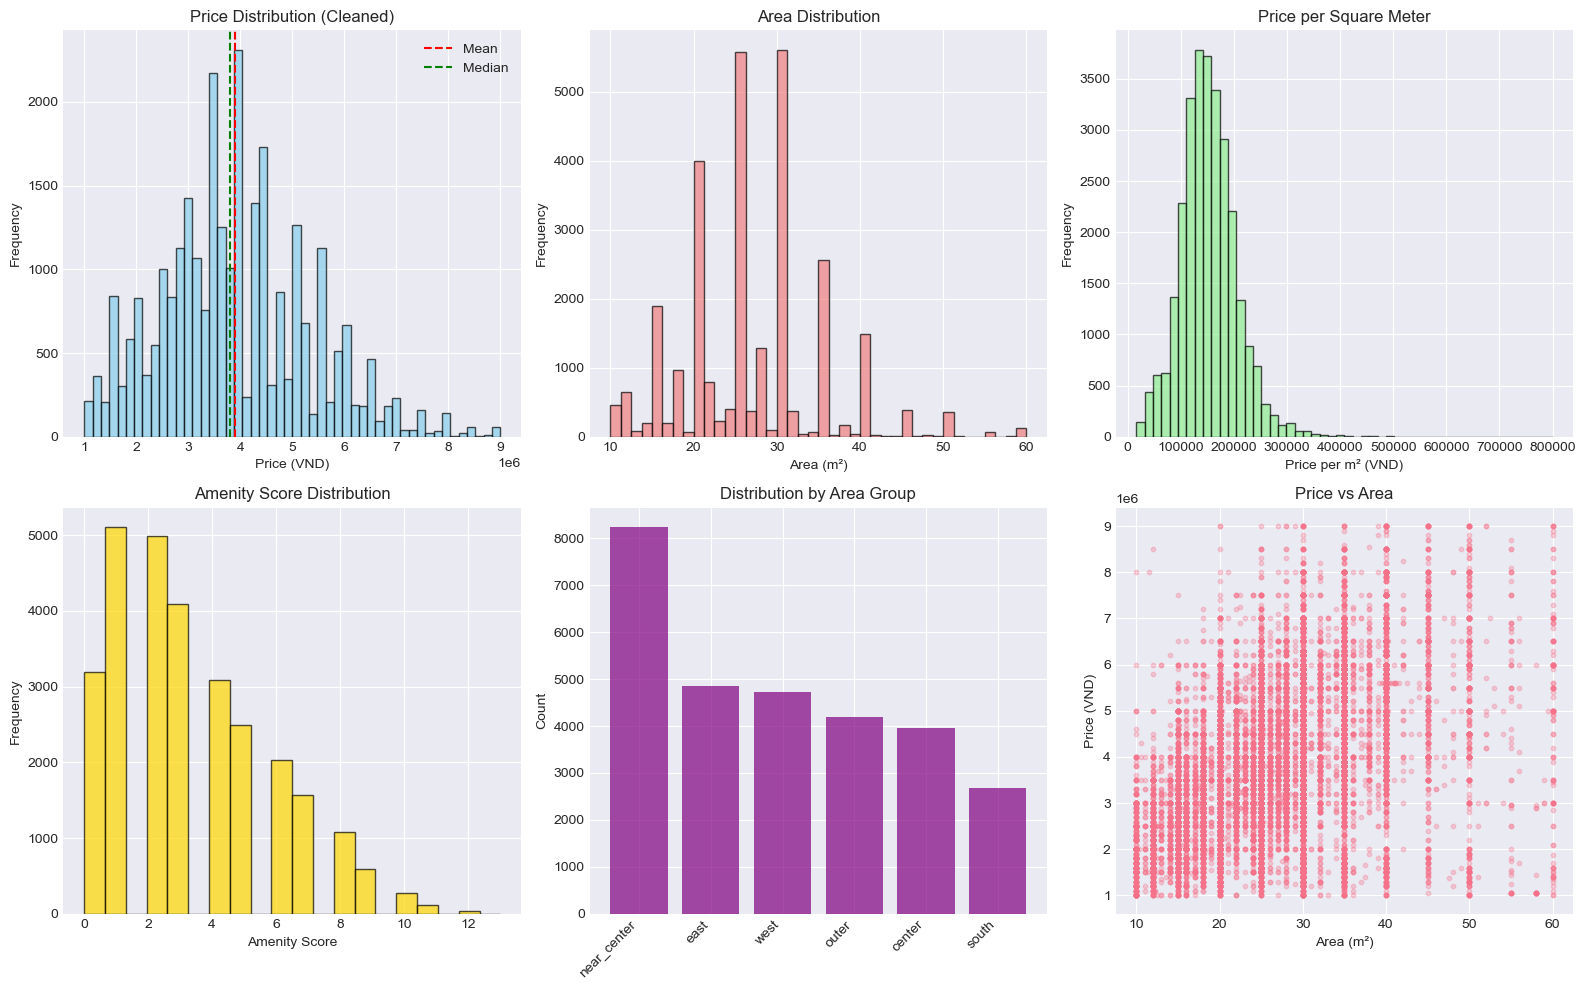

In [106]:
# Visualize final data distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Price distribution (cleaned)
axes[0, 0].hist(df_final['price'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Price (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Cleaned)')
axes[0, 0].axvline(df_final['price'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].axvline(df_final['price'].median(), color='green', linestyle='--', label='Median')
axes[0, 0].legend()

# 2. Area distribution
axes[0, 1].hist(df_final['area'], bins=40, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_xlabel('Area (m²)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Area Distribution')

# 3. Price per sqm
axes[0, 2].hist(df_final['price_per_sqm'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 2].set_xlabel('Price per m² (VND)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Price per Square Meter')

# 4. Amenity score
axes[1, 0].hist(df_final['amenity_score'], bins=20, edgecolor='black', alpha=0.7, color='gold')
axes[1, 0].set_xlabel('Amenity Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Amenity Score Distribution')

# 5. Area group
if 'area_group' in df_final.columns:
    area_counts = df_final['area_group'].value_counts()
    axes[1, 1].bar(range(len(area_counts)), area_counts.values, alpha=0.7, color='purple')
    axes[1, 1].set_xticks(range(len(area_counts)))
    axes[1, 1].set_xticklabels(area_counts.index, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Distribution by Area Group')

# 6. Price vs Area scatter
axes[1, 2].scatter(df_final['area'], df_final['price'], alpha=0.3, s=10)
axes[1, 2].set_xlabel('Area (m²)')
axes[1, 2].set_ylabel('Price (VND)')
axes[1, 2].set_title('Price vs Area')

plt.tight_layout()
plt.show()

In [109]:
# Export cleaned data
output_path = '../../data/processed/data_clean.csv'
df_final.to_csv(output_path, index=False)

print("="*70)
print("QUÁ TRÌNH XUẤT DỮ LIỆU HOÀN TẤT")
print("="*70)
print(f"\n✅ Dữ liệu sạch đã được lưu tại: {output_path}")
print(f"📊 Kích thước (Shape): {df_final.shape}")
print(f"💾 Dung lượng tệp: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n🎯 Bộ dữ liệu đã sẵn sàng cho việc huấn luyện mô hình!")
print(f"\n📋 Các bước tiếp theo:")
print(f"   1. Chia dữ liệu thành các tập huấn luyện (train) và tập kiểm thử (test)")
print(f"   2. Mã hóa các biến phân loại (Encoding categorical variables)")
print(f"   3. Chuẩn hóa các đặc trưng số (Scaling numerical features)")
print(f"   4. Xây dựng và đánh giá các mô hình dự báo")

QUÁ TRÌNH XUẤT DỮ LIỆU HOÀN TẤT

✅ Dữ liệu sạch đã được lưu tại: ../../data/processed/data_clean.csv
📊 Kích thước (Shape): (28666, 34)
💾 Dung lượng tệp: 15.52 MB

🎯 Bộ dữ liệu đã sẵn sàng cho việc huấn luyện mô hình!

📋 Các bước tiếp theo:
   1. Chia dữ liệu thành các tập huấn luyện (train) và tập kiểm thử (test)
   2. Mã hóa các biến phân loại (Encoding categorical variables)
   3. Chuẩn hóa các đặc trưng số (Scaling numerical features)
   4. Xây dựng và đánh giá các mô hình dự báo


## Tổng kết EDA & Tiền xử lý

### Các phát hiện chính:
1. **Bộ dữ liệu**: ~34k tin đăng ban đầu, sau khi loại bỏ trùng lặp, tin rác (spam) và các giá trị ngoại lai, chúng ta thu được một tập dữ liệu sạch và chất lượng cho việc xây dựng mô hình.
2. **Biến mục tiêu**: Biến `price` (giá) có phân phối **lệch phải (right-skewed)** rõ rệt. Chúng tôi đã bổ sung biến `log_price = log1p(price)` để hỗ trợ các mô hình tuyến tính đạt hiệu quả tốt hơn.
3. **Các đặc trưng quan trọng** (Dựa trên phân tích tương quan và đơn biến):
   - **Diện tích (Area)**: Có mối tương quan thuận mạnh mẽ nhất với giá thuê.
   - **Vị trí (Area group / District)**: Vị trí địa lý là yếu tố then chốt ảnh hưởng đến mặt bằng giá.
   - **Tiện ích nội thất (Amenities)**: Nội thất, máy lạnh và các tiện ích đi kèm là các yếu tố gia tăng giá trị.
   - **Đặc trưng an ninh**: Camera, bảo vệ và giờ giấc tự do.
   - **Chi phí dịch vụ**: Cho biết bài đăng phòng trọ có chứa thông tin về điện, nước, phí dịch vụ và rác.

### Các hành động xử lý chất lượng dữ liệu:
✅ Loại bỏ các dòng thiếu giá thuê (biến mục tiêu).
✅ Loại bỏ các tin đăng trùng lặp hoàn toàn và trùng lặp gần (spam/repost) dựa trên địa điểm và mức giá.
✅ Xử lý giá trị ngoại lai cho `price` và `area` bằng **ngưỡng tự động từ dữ liệu (IQR + phân vị 1%–99%)**, thay vì áp đặt các con số cố định (hard-code) như 500k–30M hay 5–200m².
✅ Làm sạch chi phí dịch vụ bằng **ngưỡng phân vị 1%–99% riêng biệt cho từng cột** và lấp đầy (impute) phần còn thiếu bằng giá trị trung vị (median).
✅ Xử lý dữ liệu khuyết cho biến phân loại bằng cách tạo nhóm `'unknown'` hoặc loại bỏ nếu thiếu thông tin vị trí bắt buộc.
✅ Trích xuất các **đặc trưng mới (Feature Engineering)**: `price_per_sqm`, `total_utility_cost`, `amenity_score`, `log_price`,….
✅ Loại bỏ các cột văn bản không sử dụng trực tiếp trong các mô hình học máy dạng bảng cơ bản.

### Sẵn sàng cho giai đoạn Huấn luyện mô hình:
- Tập dữ liệu hiện tại đã **sạch, nhất quán và được làm giàu bởi các đặc trưng kỹ thuật**.
- Quy trình đã sẵn sàng để thử nghiệm các mô hình: Linear/ElasticNet trên `log_price`, hoặc các mô hình mạnh mẽ hơn như Random Forest / XGBoost / LightGBM trên các đặc trưng dạng bảng; kết hợp với các pipeline mã hóa (encoding) và chuẩn hóa (scaling) phù hợp.